In [1]:
from keras.layers import Input, Dense
from keras.models import Model, Sequential
from keras import regularizers
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.manifold import TSNE
from sklearn import preprocessing 
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns
from numpy import sum,isrealobj,sqrt
from numpy.random import standard_normal

from Modules.Tools import MapTool
from Modules.Tools import csv2Numpy
from Modules.Tools import BoxPlot
from Modules.Tools import peakCorrelation as pC 
import random

In [2]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 17735787615537919955
 xla_global_id: -1]

In [3]:
def printandwrite(loc, text, firstLine = False):       
    print(text)
    if firstLine:
        sourceFile = open(loc, 'w')
    else:
        sourceFile = open(loc, 'a')
    sourceFile.write(text)
    sourceFile.close()

In [4]:
params = {'legend.fontsize': 50,
          'figure.figsize': (45, 15),
         'axes.labelsize': 60,
         'axes.titlesize':70,
         'xtick.labelsize':50,
         'ytick.labelsize':50,
          'font.weight': "bold",
         'lines.linewidth': 5}
plt.rcParams.update(params)

In [5]:
pad = 8

# Load Dataset

In [6]:
load_Folder = "./Datasets/FP_GANs_LargeScale_2/k-Fold/TrainingDatasets/"

## Real normal

In [7]:
alpha = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/segment/Alpha/Alpha_segment.npy", allow_pickle=True)

alpha_MP = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/Major_Peaks/Alpha/Alpha_major_peaks.npy", allow_pickle=True)

## Real Anomalous

In [8]:
alpha_sub = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/segment/Alpha_sub/Alpha_sub_segment.npy", allow_pickle=True)

alpha_sub_MP = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/Major_Peaks/Alpha_sub/Alpha_sub_major_peaks.npy", allow_pickle=True)

# Create method to apply noise to all signals in a dataset

In [9]:
# author - Mathuranathan Viswanathan (gaussianwaves.com
# This code is part of the book Digital Modulations using Python

def addNoise(s,SNRdB,L=1):   
    gamma = 10**(SNRdB/10)             # SNR to linear scale
    if s.ndim==1:                      # if s is single dimensional vector
        P=L*sum(abs(s)**2)/len(s)      # Actual power in the vector
    else:                              # multi-dimensional signals like MFSK
        P=L*sum(sum(abs(s)**2))/len(s)     # if s is a matrix [MxN]
    N0=P/gamma                         # Find the noise spectral density
    if isrealobj(s):                   # check if input is real/complex object type
        n = sqrt(N0/2)*standard_normal(s.shape) # computed noise
    else:
        n = sqrt(N0/2)*(standard_normal(s.shape)+1j*standard_normal(s.shape))
    r = s + n # received signal

    return r

In [10]:
# Takes each signal in the dataset and applies WGN.
def addNoiseDS(dataset, SNR):
    new_Dataset = np.copy(dataset)
    for s in range(new_Dataset.shape[0]):
        new_Dataset[s] = addNoise(new_Dataset[s],SNR)
    return new_Dataset

In [18]:
alpha_SNR_50 = addNoiseDS(alpha,50)
alpha_SNR_40 = addNoiseDS(alpha,40)
alpha_SNR_30 = addNoiseDS(alpha,30)
alpha_SNR_25 = addNoiseDS(alpha,25)
alpha_SNR_20 = addNoiseDS(alpha,20)
alpha_SNR_15 = addNoiseDS(alpha,15)
alpha_SNR_14 = addNoiseDS(alpha,14)
alpha_SNR_13 = addNoiseDS(alpha,13)
alpha_SNR_12 = addNoiseDS(alpha,12)
alpha_SNR_11 = addNoiseDS(alpha,11)
alpha_SNR_10 = addNoiseDS(alpha,10)
alpha_SNR_8 = addNoiseDS(alpha,8)
alpha_SNR_5 = addNoiseDS(alpha,5)

alpha_sub_SNR_50 = addNoiseDS(alpha_sub,50)
alpha_sub_SNR_40 = addNoiseDS(alpha_sub,40)
alpha_sub_SNR_30 = addNoiseDS(alpha_sub,30)
alpha_sub_SNR_25 = addNoiseDS(alpha_sub,25)
alpha_sub_SNR_20 = addNoiseDS(alpha_sub,20)
alpha_sub_SNR_15 = addNoiseDS(alpha_sub,15)
alpha_sub_SNR_14 = addNoiseDS(alpha_sub,14)
alpha_sub_SNR_13 = addNoiseDS(alpha_sub,13)
alpha_sub_SNR_12 = addNoiseDS(alpha_sub,12)
alpha_sub_SNR_11 = addNoiseDS(alpha_sub,11)
alpha_sub_SNR_10 = addNoiseDS(alpha_sub,10)
alpha_sub_SNR_8 = addNoiseDS(alpha_sub,8)
alpha_sub_SNR_5 = addNoiseDS(alpha_sub,5)

# Obtain major peaks

In [12]:
'''
Method will obtain only the major peaks of the signal in the range of the peaks provided.

Signals: signals to extract the major peaks.
Start_Peak: Starting peak to extract from each signal.
End_Peak: Final peak to exatract from each signal
'''
def ObtainMajorPeaks(Signals, pad=pad):
    ## extract the peaks only
    Baseline_peaks = MapTool.getPeaksDataset(Signals, pad)
    
    print(Baseline_peaks.shape)
    shapes = []
    i = 0
    for signal in Baseline_peaks:
        if signal.shape[0] == 24:
            print(i)
        shapes.append(signal.shape[0])
        i = i +1
    print(np.unique(np.array(shapes)))
    
    ## remove the end peak
    Baseline_peaks = Baseline_peaks[:,:Baseline_peaks.shape[1]-1]

    ## obtain only the major peaks removing the inbetween low peak.
    Baseline = []
    for n in range(Baseline_peaks.shape[0]):
        major_peaks = []
        for q in range(Baseline_peaks[n].shape[0]):
            if q%2 == 0:
                major_peaks.append(Baseline_peaks[n][q])
        Baseline.append(major_peaks)

    Baseline = np.array(Baseline, dtype=object)
    
    return Baseline

In [13]:
def resetArray(dataset):
    new_array = []
    for signal in dataset:
        new_array.append(signal)
    return np.array(new_array, dtype=object)

In [14]:
'''
Method will obtain only the major peaks of the signal in the range of the peaks provided.

Signals: signals to extract the major peaks.
Start_Peak: Starting peak to extract from each signal.
End_Peak: Final peak to exatract from each signal
'''
def ObtainMajorPeaks_Set(Signals, pad=pad,length=25):
    ## extract the peaks only
    Baseline_peaks = MapTool.getPeaksDataset(Signals, pad)
    print(Baseline_peaks.shape)
    shapes = []
    i = 0
    for signal in Baseline_peaks:
        if signal.shape[0] != length:
            print(i)
        shapes.append(signal.shape[0])
        i = i +1
    
    # Try with different pad
    for i in range(Baseline_peaks.shape[0]):
        amount = 3
        check = 1
        if Baseline_peaks[i].shape[0] != length:
            check = 0
        old_pad = pad
        while check == 0:
            new_pad = old_pad - 1
            if Baseline_peaks[i].shape[0] != length:
                check = 0
                Baseline_peaks[i] = MapTool.getPeaks(Signals[i], pad-1)
                amount = amount -1
                old_pad = new_pad
                if amount == 0:
                    check = 1
            else:
                check = 1
    
    Baseline_peaks = resetArray(Baseline_peaks)
    print(Baseline_peaks.shape)
    shapes = []
    i = 0
    for signal in Baseline_peaks:
        if signal.shape[0] != length:
            print(i)
        shapes.append(signal.shape[0])
        i = i +1
        
    # if still fails take a random sample.
    for i in range(Baseline_peaks.shape[0]):
        amount = 3
        check = 1
        if Baseline_peaks[i].shape[0] != length:
            check = 0
        while check == 0:
            if Baseline_peaks[i].shape[0] != length:
                check = 0
                # Get random sample
                q = random.randint(0, Baseline_peaks.shape[0]-1)
                Baseline_peaks[i] = Baseline_peaks[q]
                amount = amount -1
                old_pad = new_pad
                if amount == 0:
                    check = 1
            else:
                check = 1
       
    Baseline_peaks = resetArray(Baseline_peaks)
    print(Baseline_peaks.shape)
    shapes = []
    i = 0
    for signal in Baseline_peaks:
        if signal.shape[0] == 24:
            print(i)
        shapes.append(signal.shape[0])
        i = i +1
                
    ## remove the end peak
    Baseline_peaks = Baseline_peaks[:,:Baseline_peaks.shape[1]-1]

    ## obtain only the major peaks removing the inbetween low peak.
    Baseline = []
    for n in range(Baseline_peaks.shape[0]):
        major_peaks = []
        for q in range(Baseline_peaks[n].shape[0]):
            if q%2 == 0:
                major_peaks.append(Baseline_peaks[n][q])
        Baseline.append(major_peaks)

    Baseline = np.array(Baseline, dtype=object)
    
    return Baseline

In [16]:
random.randint(0, 3000)

1551

In [20]:
alpha_SNR_50_MP = ObtainMajorPeaks(alpha_SNR_50)
alpha_SNR_40_MP = ObtainMajorPeaks(alpha_SNR_40)
alpha_SNR_30_MP = ObtainMajorPeaks(alpha_SNR_30)
alpha_SNR_25_MP = ObtainMajorPeaks(alpha_SNR_25)
alpha_SNR_20_MP = ObtainMajorPeaks(alpha_SNR_20)
alpha_SNR_15_MP = ObtainMajorPeaks(alpha_SNR_15)
alpha_SNR_10_MP = ObtainMajorPeaks(alpha_SNR_10)

alpha_sub_SNR_50_MP = ObtainMajorPeaks(alpha_sub_SNR_50)
alpha_sub_SNR_40_MP = ObtainMajorPeaks(alpha_sub_SNR_40)
alpha_sub_SNR_30_MP = ObtainMajorPeaks(alpha_sub_SNR_30)
alpha_sub_SNR_25_MP = ObtainMajorPeaks(alpha_sub_SNR_25)
alpha_sub_SNR_20_MP = ObtainMajorPeaks(alpha_sub_SNR_20)
alpha_sub_SNR_15_MP = ObtainMajorPeaks(alpha_sub_SNR_15)
alpha_sub_SNR_10_MP = ObtainMajorPeaks(alpha_sub_SNR_10)

(3000, 25)
[25]
(3000, 25)
[25]
(3000, 25)
[25]
(3000, 25)
[25]
(3000, 25)
[25]
(3000, 25)
[25]
(3000, 25)
[25]
(3000, 25)
[25]
(3000, 25)
[25]
(3000, 25)
[25]
(3000, 25)
[25]
(3000, 25)
[25]
(1312, 27)
[27]
(1312, 27)
[27]
(1312, 27)
[27]
(1312, 27)
[27]
(1312, 27)
[27]
(1312, 27)
[27]
(1312, 27)
[27]
(1312, 27)
[27]
(1312, 27)
[27]
(1312, 27)
[27]
(1312, 27)
[27]
(1312, 27)
[27]


In [136]:
echo_SNR_50_MP = ObtainMajorPeaks(echo_SNR_50)
echo_SNR_40_MP = ObtainMajorPeaks(echo_SNR_40)
echo_SNR_30_MP = ObtainMajorPeaks(echo_SNR_30)
echo_SNR_25_MP = ObtainMajorPeaks(echo_SNR_25)
echo_SNR_20_MP = ObtainMajorPeaks(echo_SNR_20)
echo_SNR_15_MP = ObtainMajorPeaks(echo_SNR_15)
echo_SNR_10_MP = ObtainMajorPeaks(echo_SNR_10)

echo_sub_SNR_50_MP = ObtainMajorPeaks(echo_sub_SNR_50)
echo_sub_SNR_40_MP = ObtainMajorPeaks(echo_sub_SNR_40)
echo_sub_SNR_30_MP = ObtainMajorPeaks(echo_sub_SNR_30)
echo_sub_SNR_25_MP = ObtainMajorPeaks(echo_sub_SNR_25)
echo_sub_SNR_20_MP = ObtainMajorPeaks(echo_sub_SNR_20)
echo_sub_SNR_15_MP = ObtainMajorPeaks(echo_sub_SNR_15)
echo_sub_SNR_10_MP = ObtainMajorPeaks(echo_sub_SNR_10)

IndexError: tuple index out of range

# Obtain graphs

## Alpha

### Full

In [186]:
signal_original = alpha[0]
signal_50 = alpha_SNR_50[0]
signal_40 = alpha_SNR_40[0]
signal_30 = alpha_SNR_30[0]
signal_25 = alpha_SNR_25[0]
signal_20 = alpha_SNR_20[0]
signal_15 = alpha_SNR_15[0]
signal_10 = alpha_SNR_10[0]

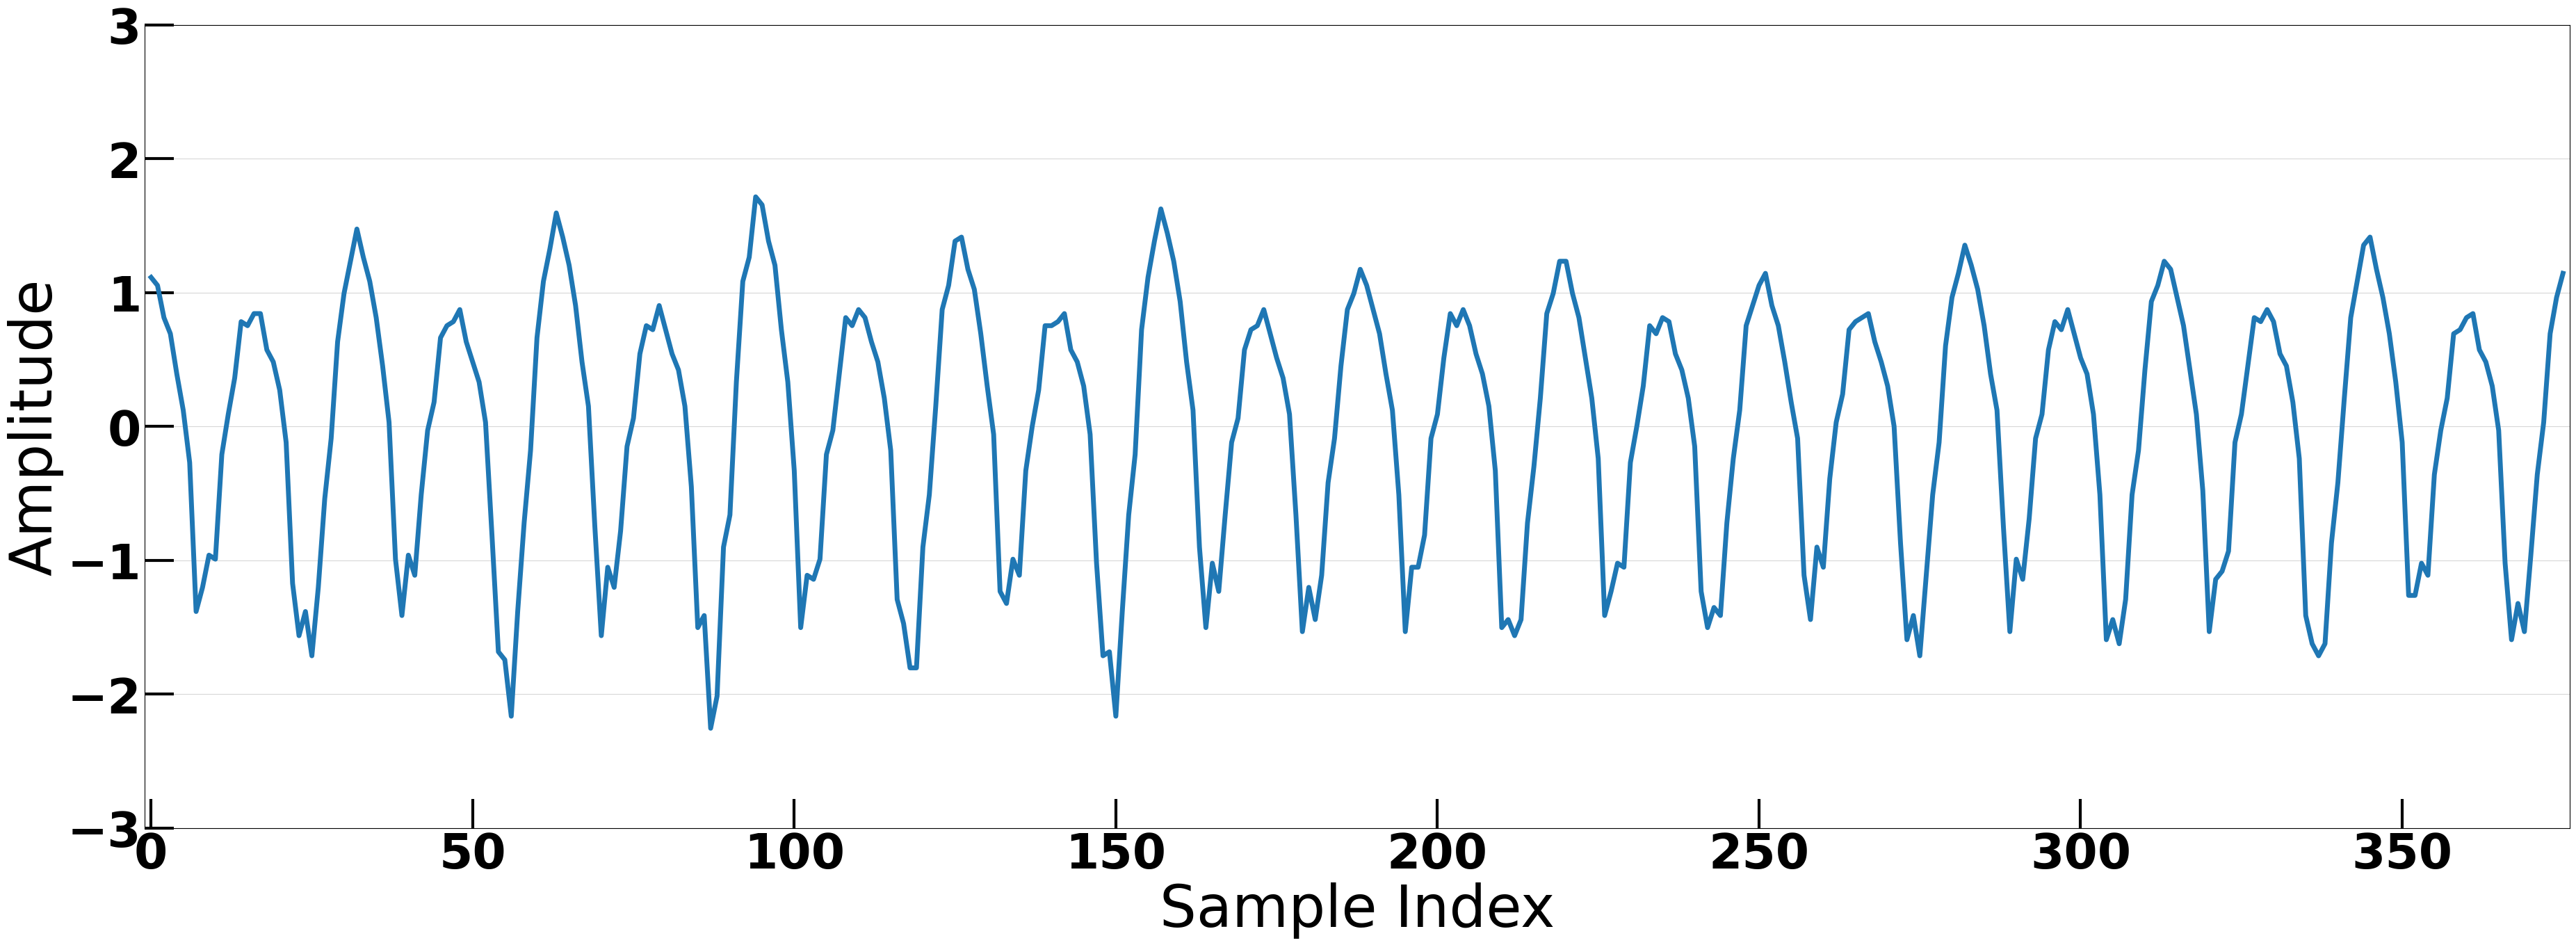

In [187]:
time_Signal = np.arange(signal_original.shape[0])
plt.plot(time_Signal, signal_original, label="", markersize=30)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.xlim([-1,len(signal_original)])
plt.ylim(-3,3)
#plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Full/" + "alpha_No_Noise.png", bbox_inches='tight') 
plt.show()  
plt.close()

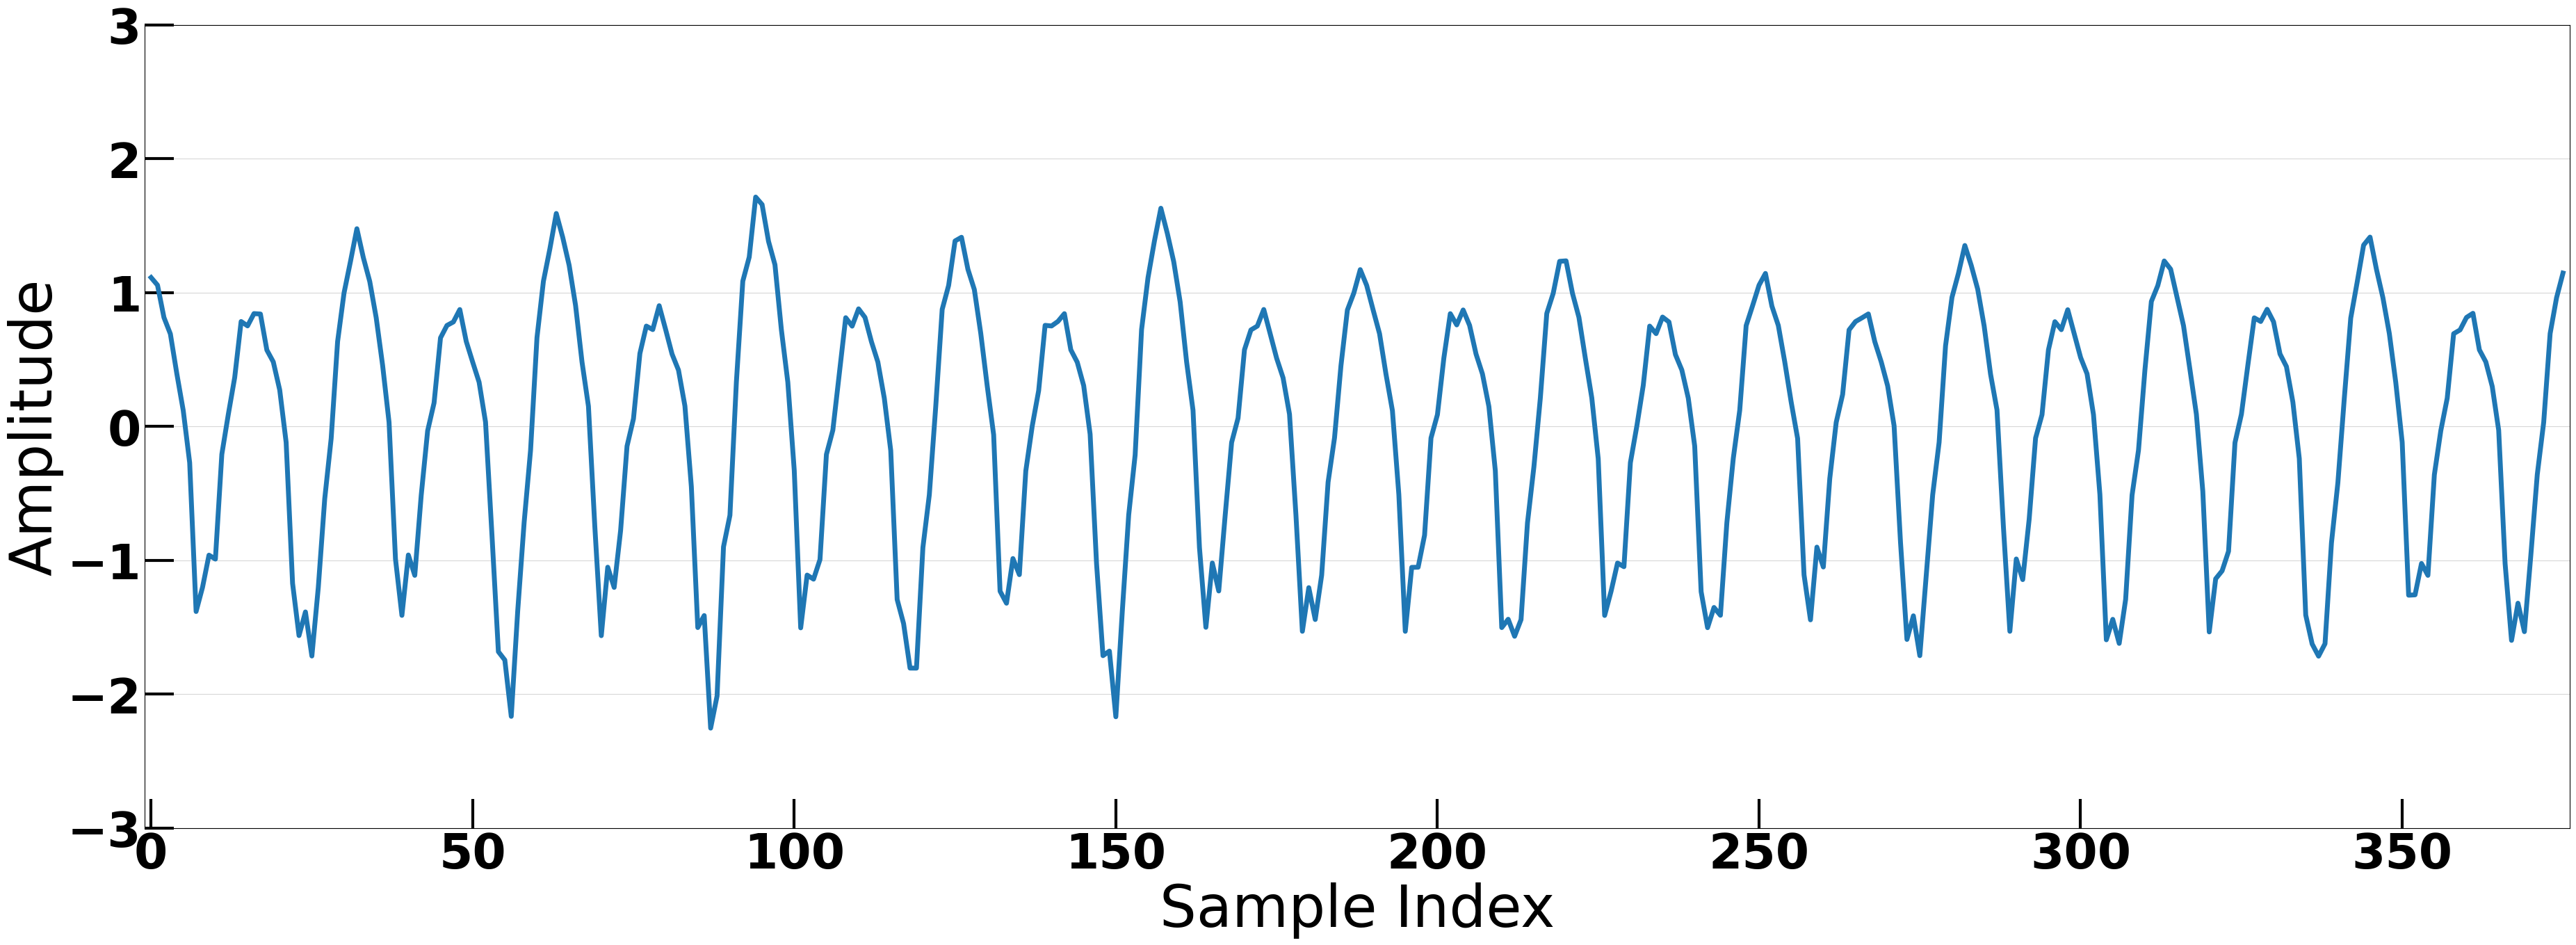

In [188]:
time_Signal = np.arange(signal_50.shape[0])
plt.plot(time_Signal, signal_50, label="", markersize=30)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.xlim([-1,len(signal_original)])
plt.ylim(-3,3)
#plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Full/" + "alpha_50.png", bbox_inches='tight')    
plt.show()
plt.close()

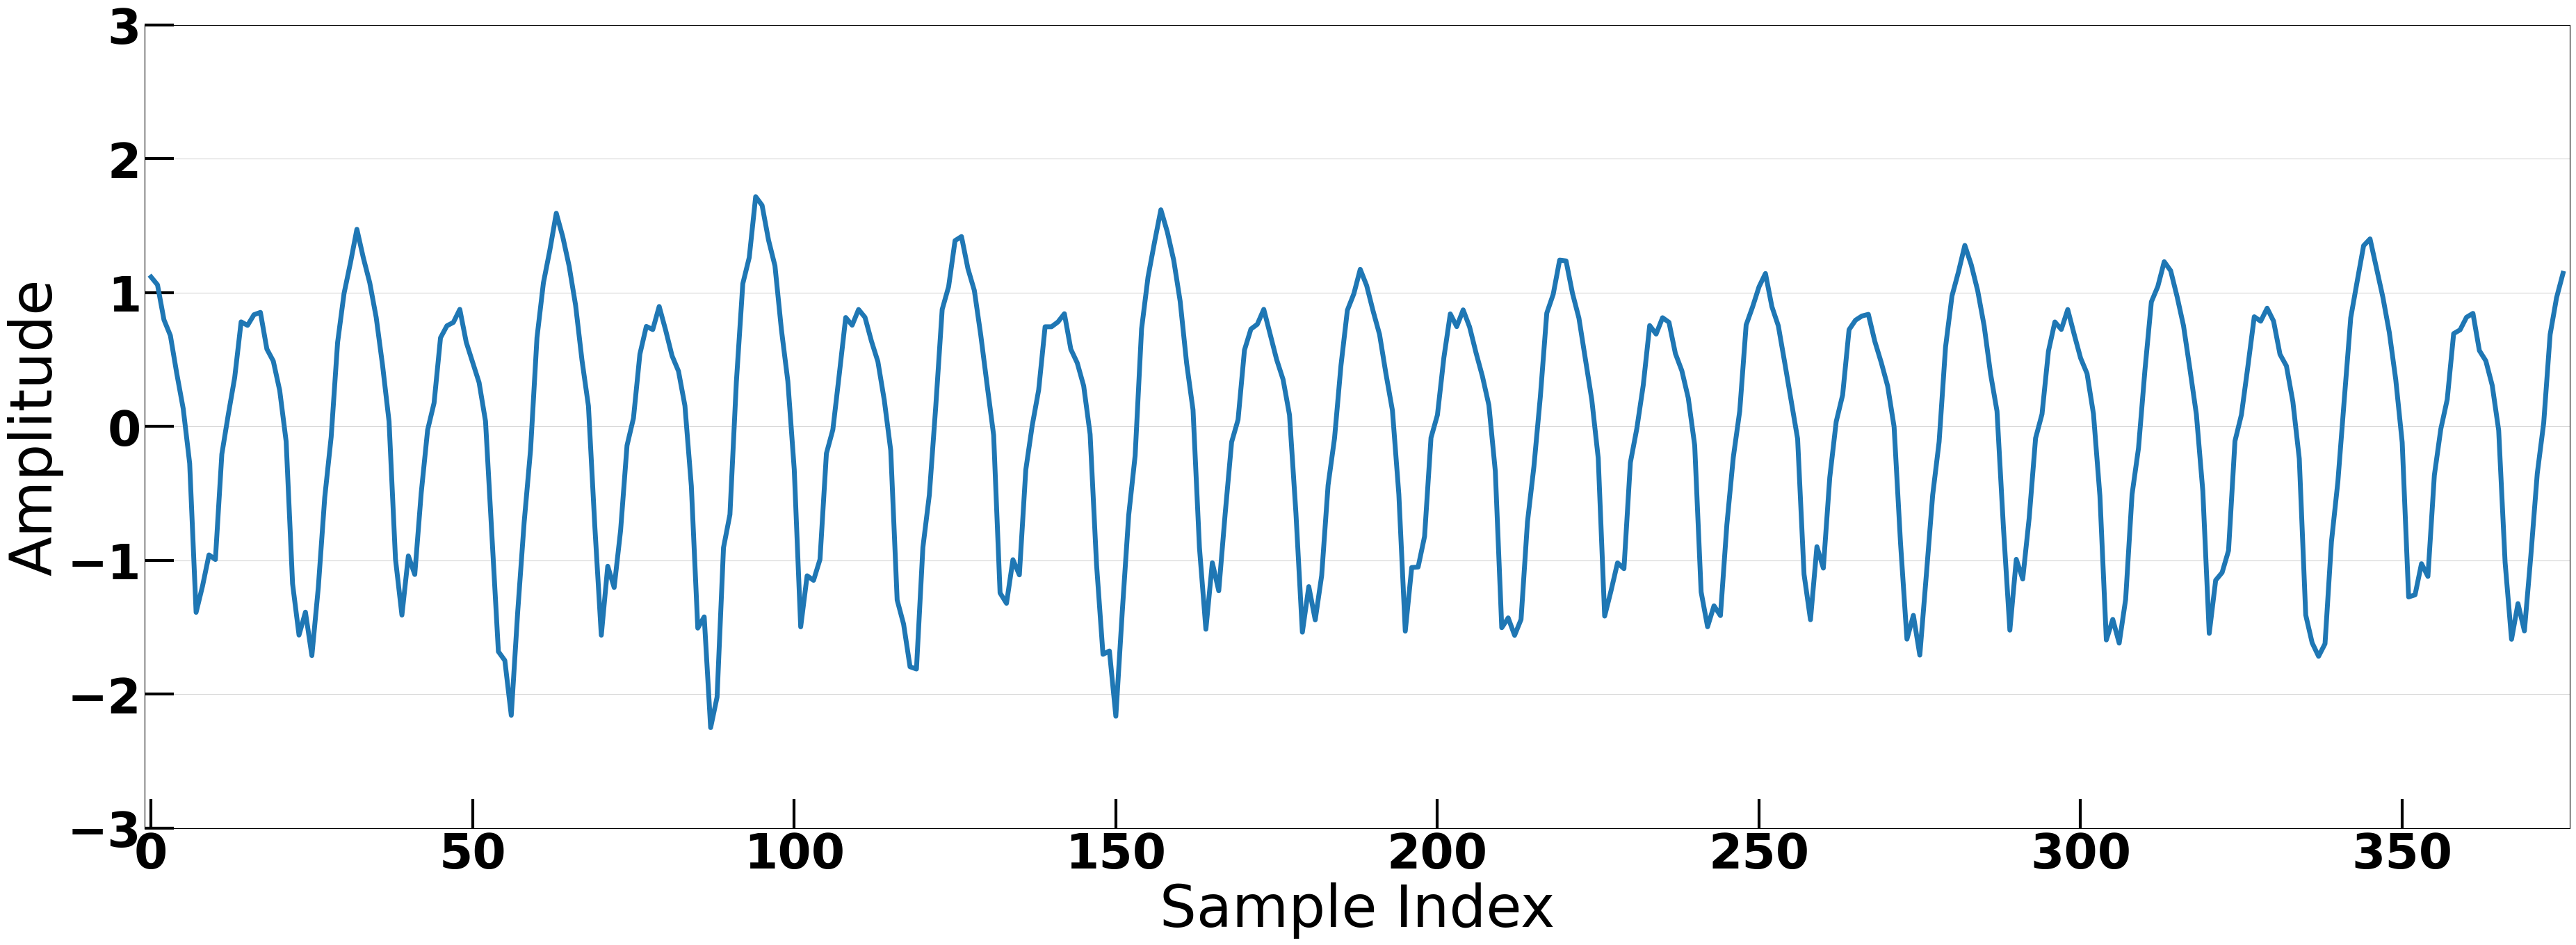

In [189]:
time_Signal = np.arange(signal_40.shape[0])
plt.plot(time_Signal, signal_40, label="", markersize=30)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.xlim([-1,len(signal_original)])
plt.ylim(-3,3)
#plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Full/" + "alpha_40.png", bbox_inches='tight')    
plt.show()
plt.close()

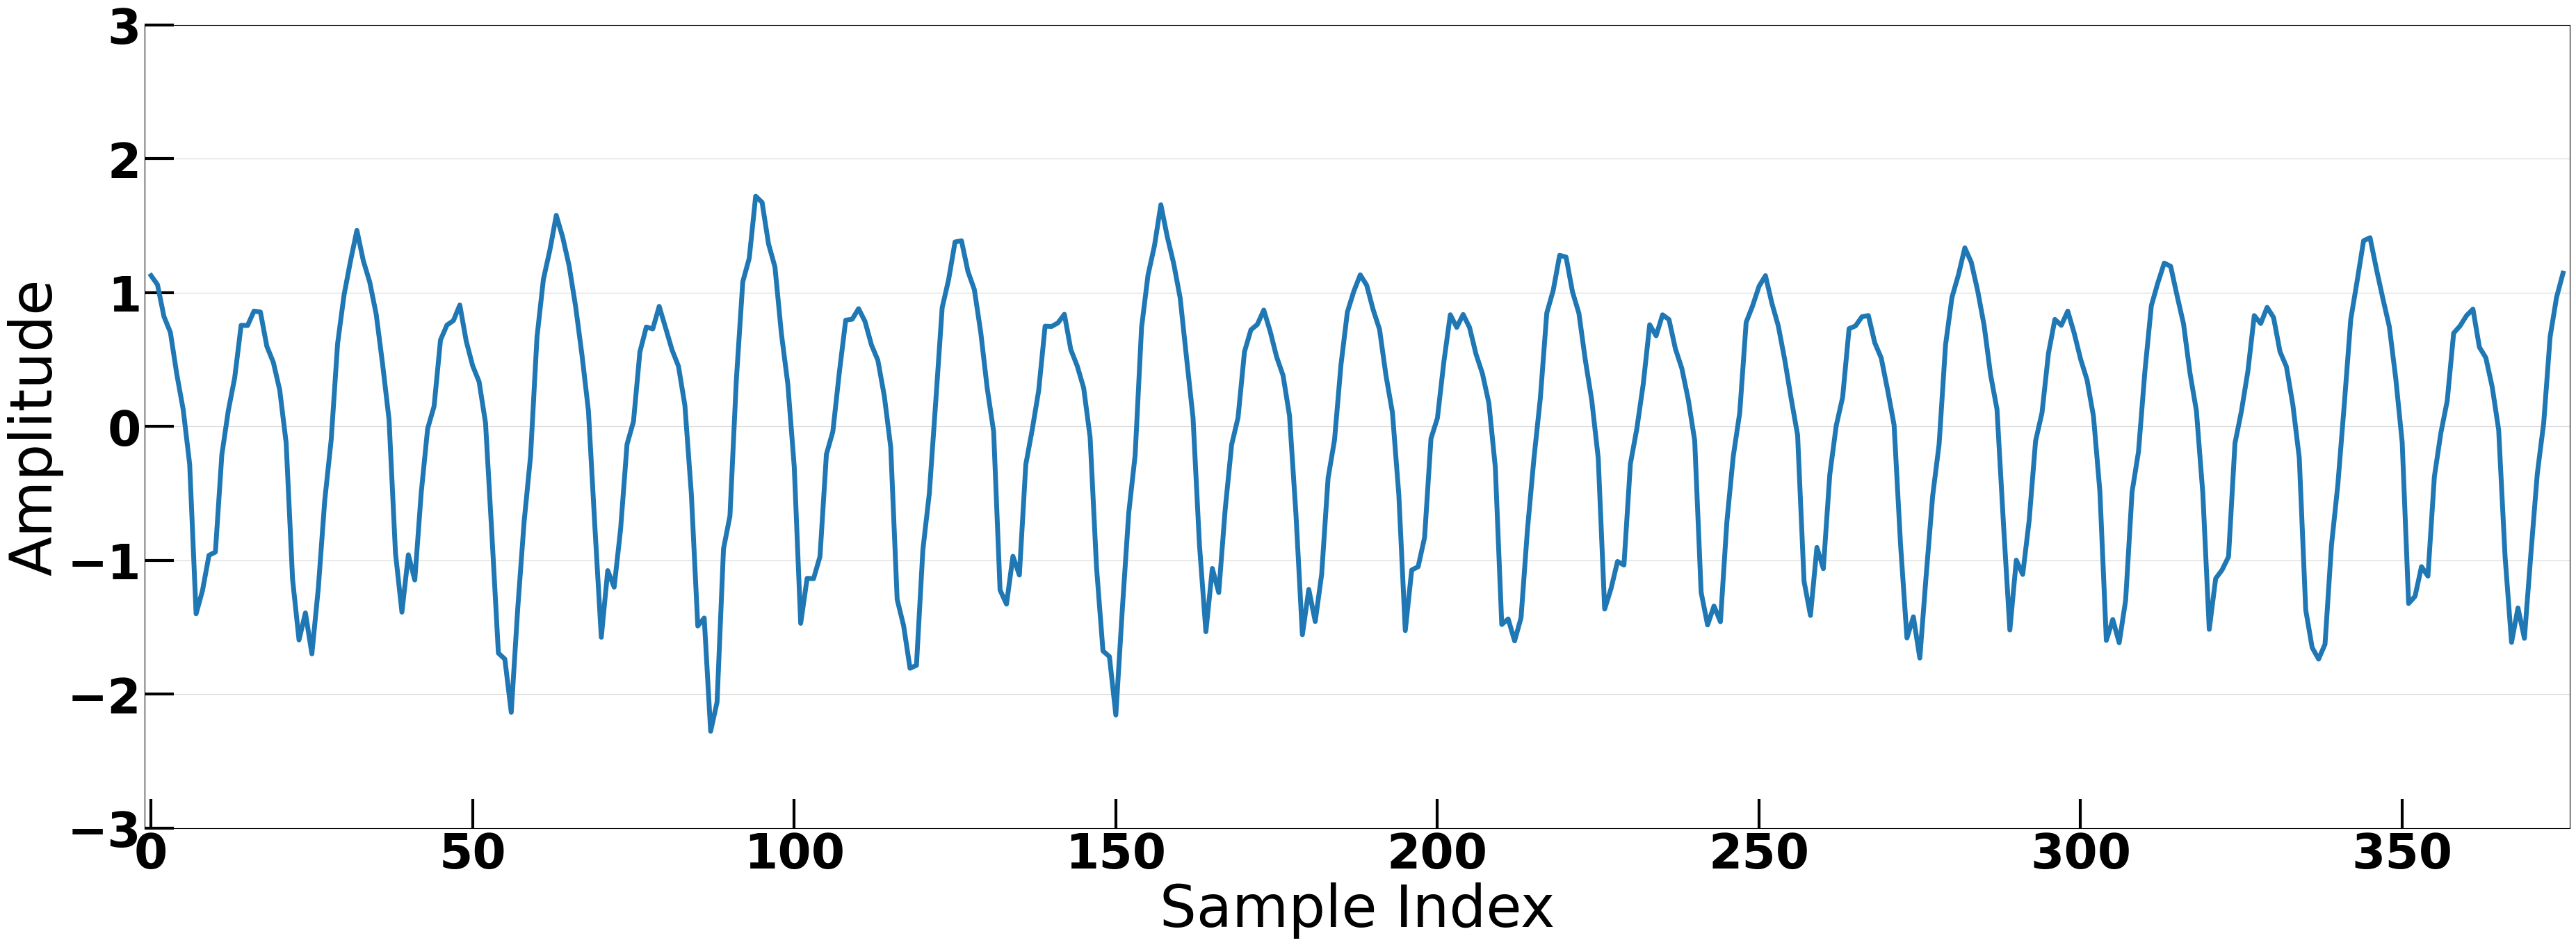

In [190]:
time_Signal = np.arange(signal_30.shape[0])
plt.plot(time_Signal, signal_30, label="", markersize=30)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.xlim([-1,len(signal_original)])
plt.ylim(-3,3)
#plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Full/" + "alpha_30.png", bbox_inches='tight')    
plt.show()
plt.close()

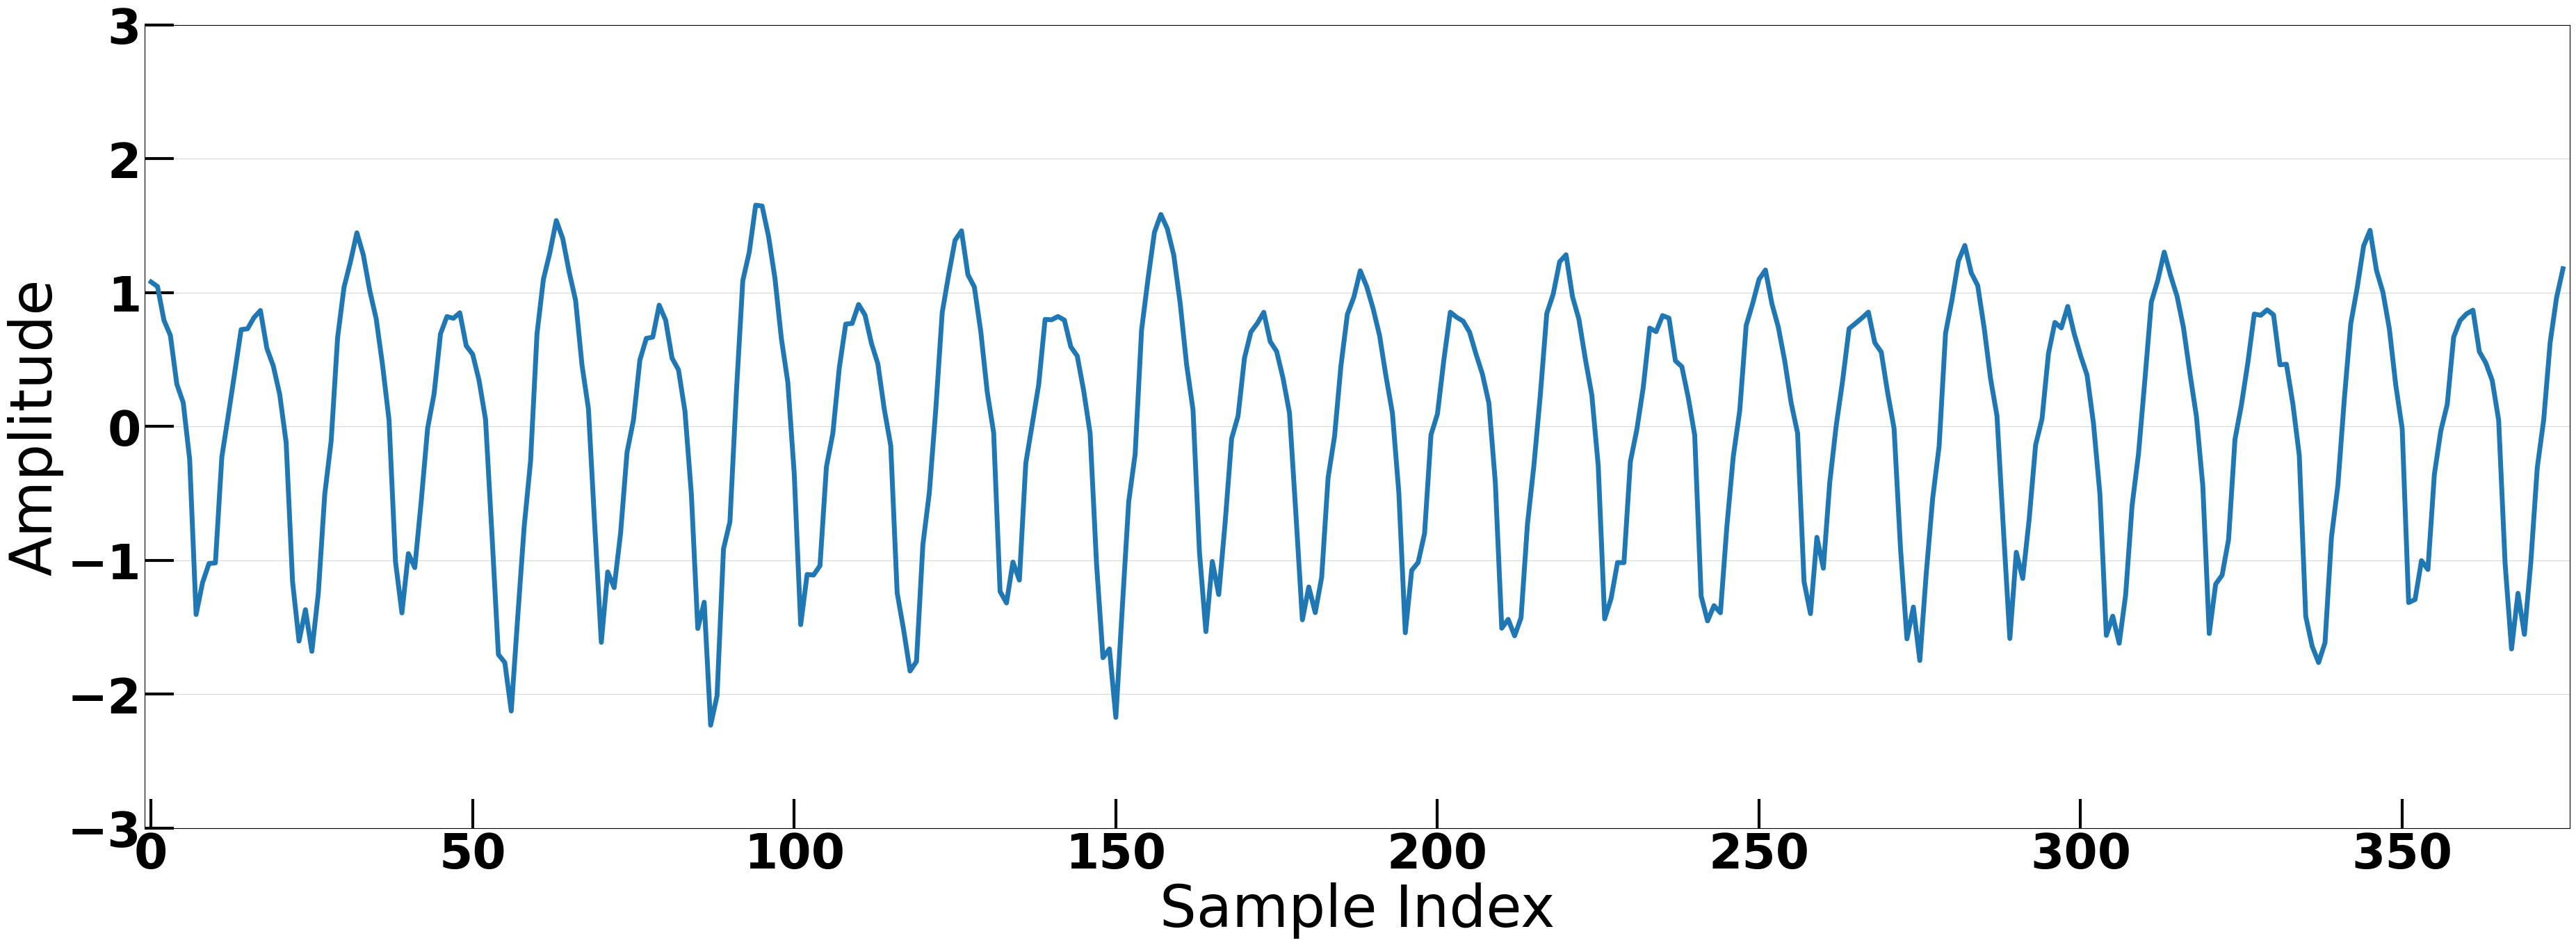

In [191]:
time_Signal = np.arange(signal_25.shape[0])
plt.plot(time_Signal, signal_25, label="", markersize=30)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.xlim([-1,len(signal_original)])
plt.ylim(-3,3)
#plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Full/" + "alpha_25.png", bbox_inches='tight')    
plt.show()
plt.close()

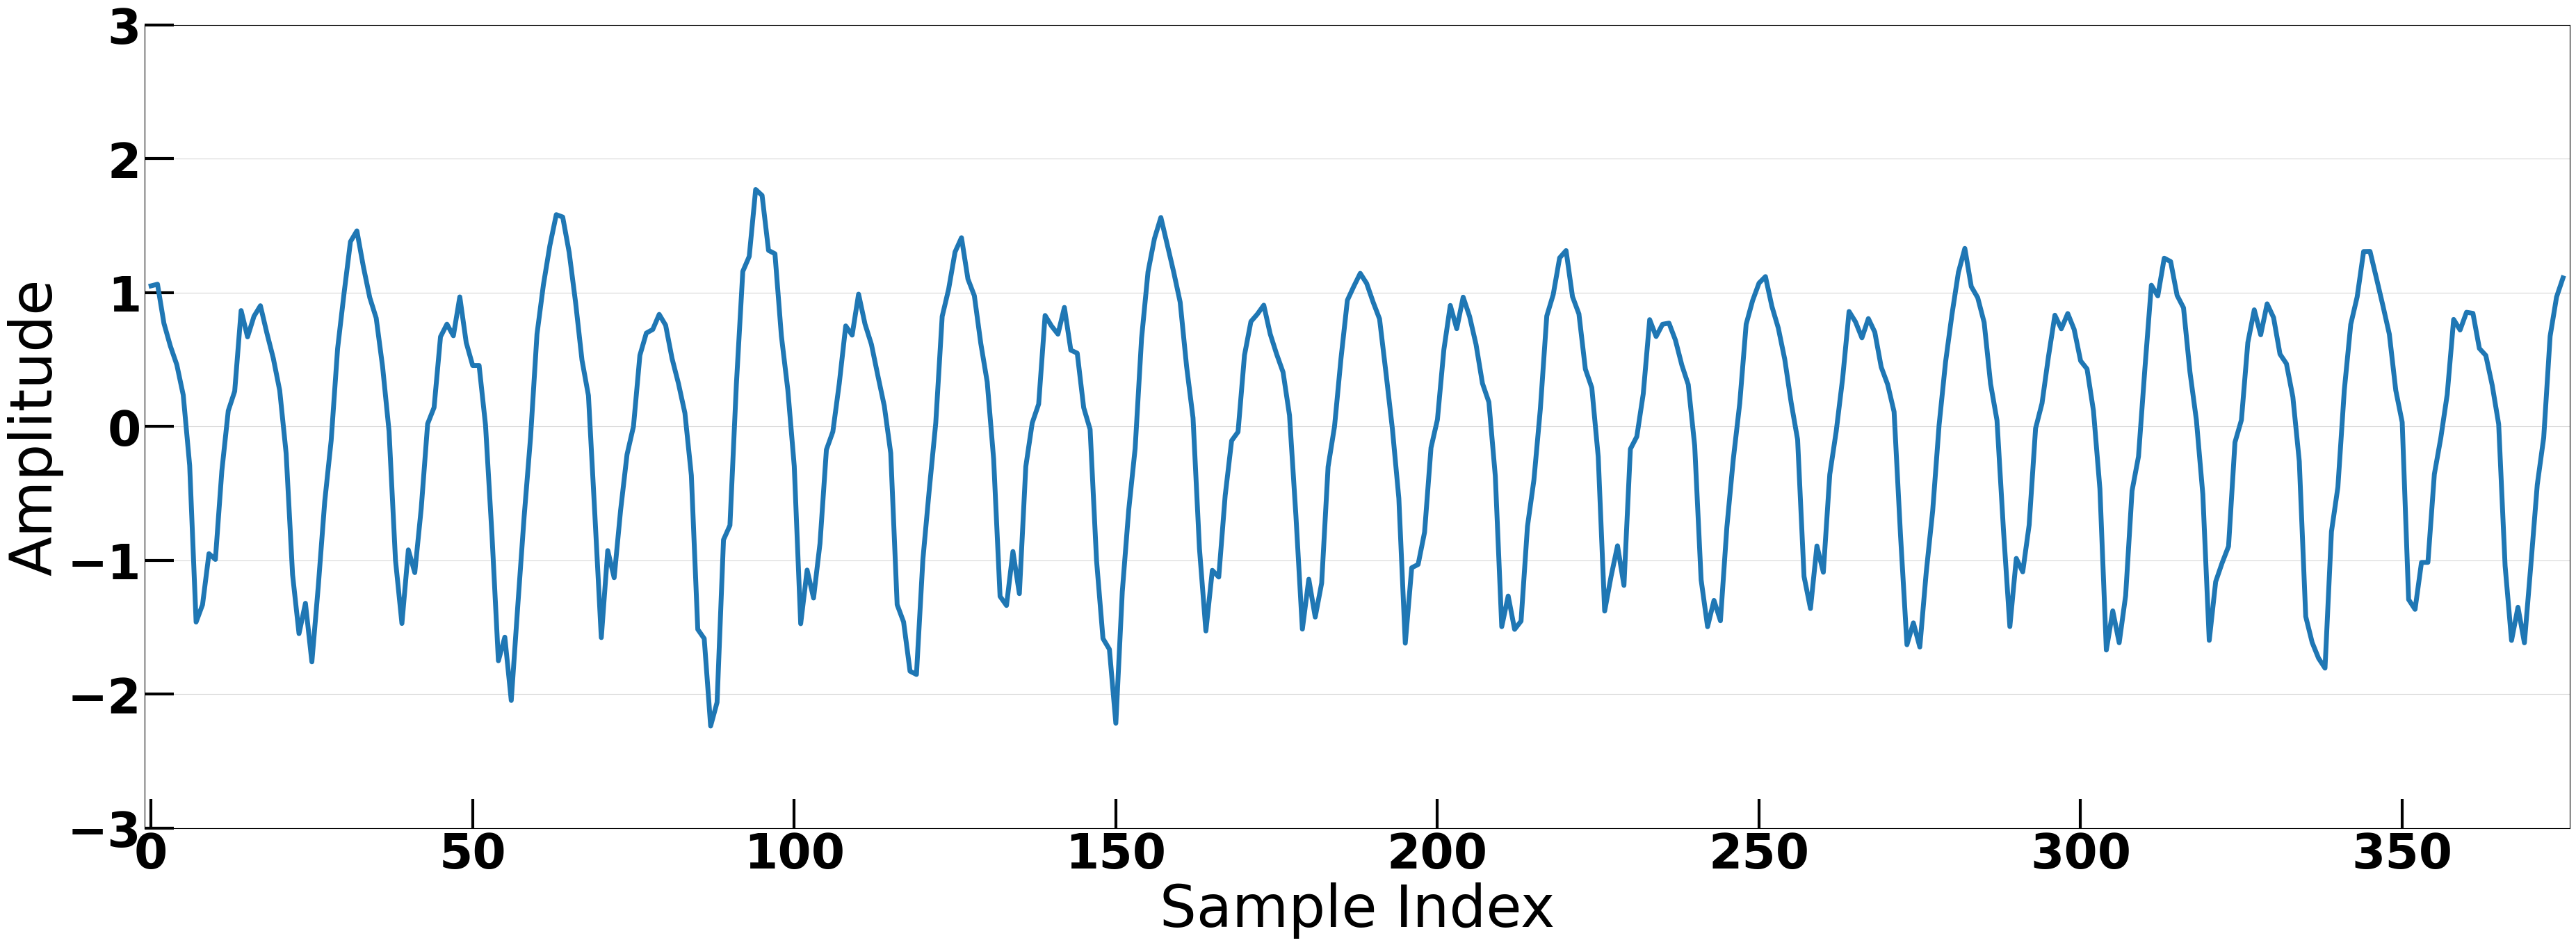

In [192]:
time_Signal = np.arange(signal_20.shape[0])
plt.plot(time_Signal, signal_20, label="", markersize=30)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.xlim([-1,len(signal_original)])
plt.ylim(-3,3)
#plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Full/" + "alpha_20.png", bbox_inches='tight')    
plt.show()
plt.close()

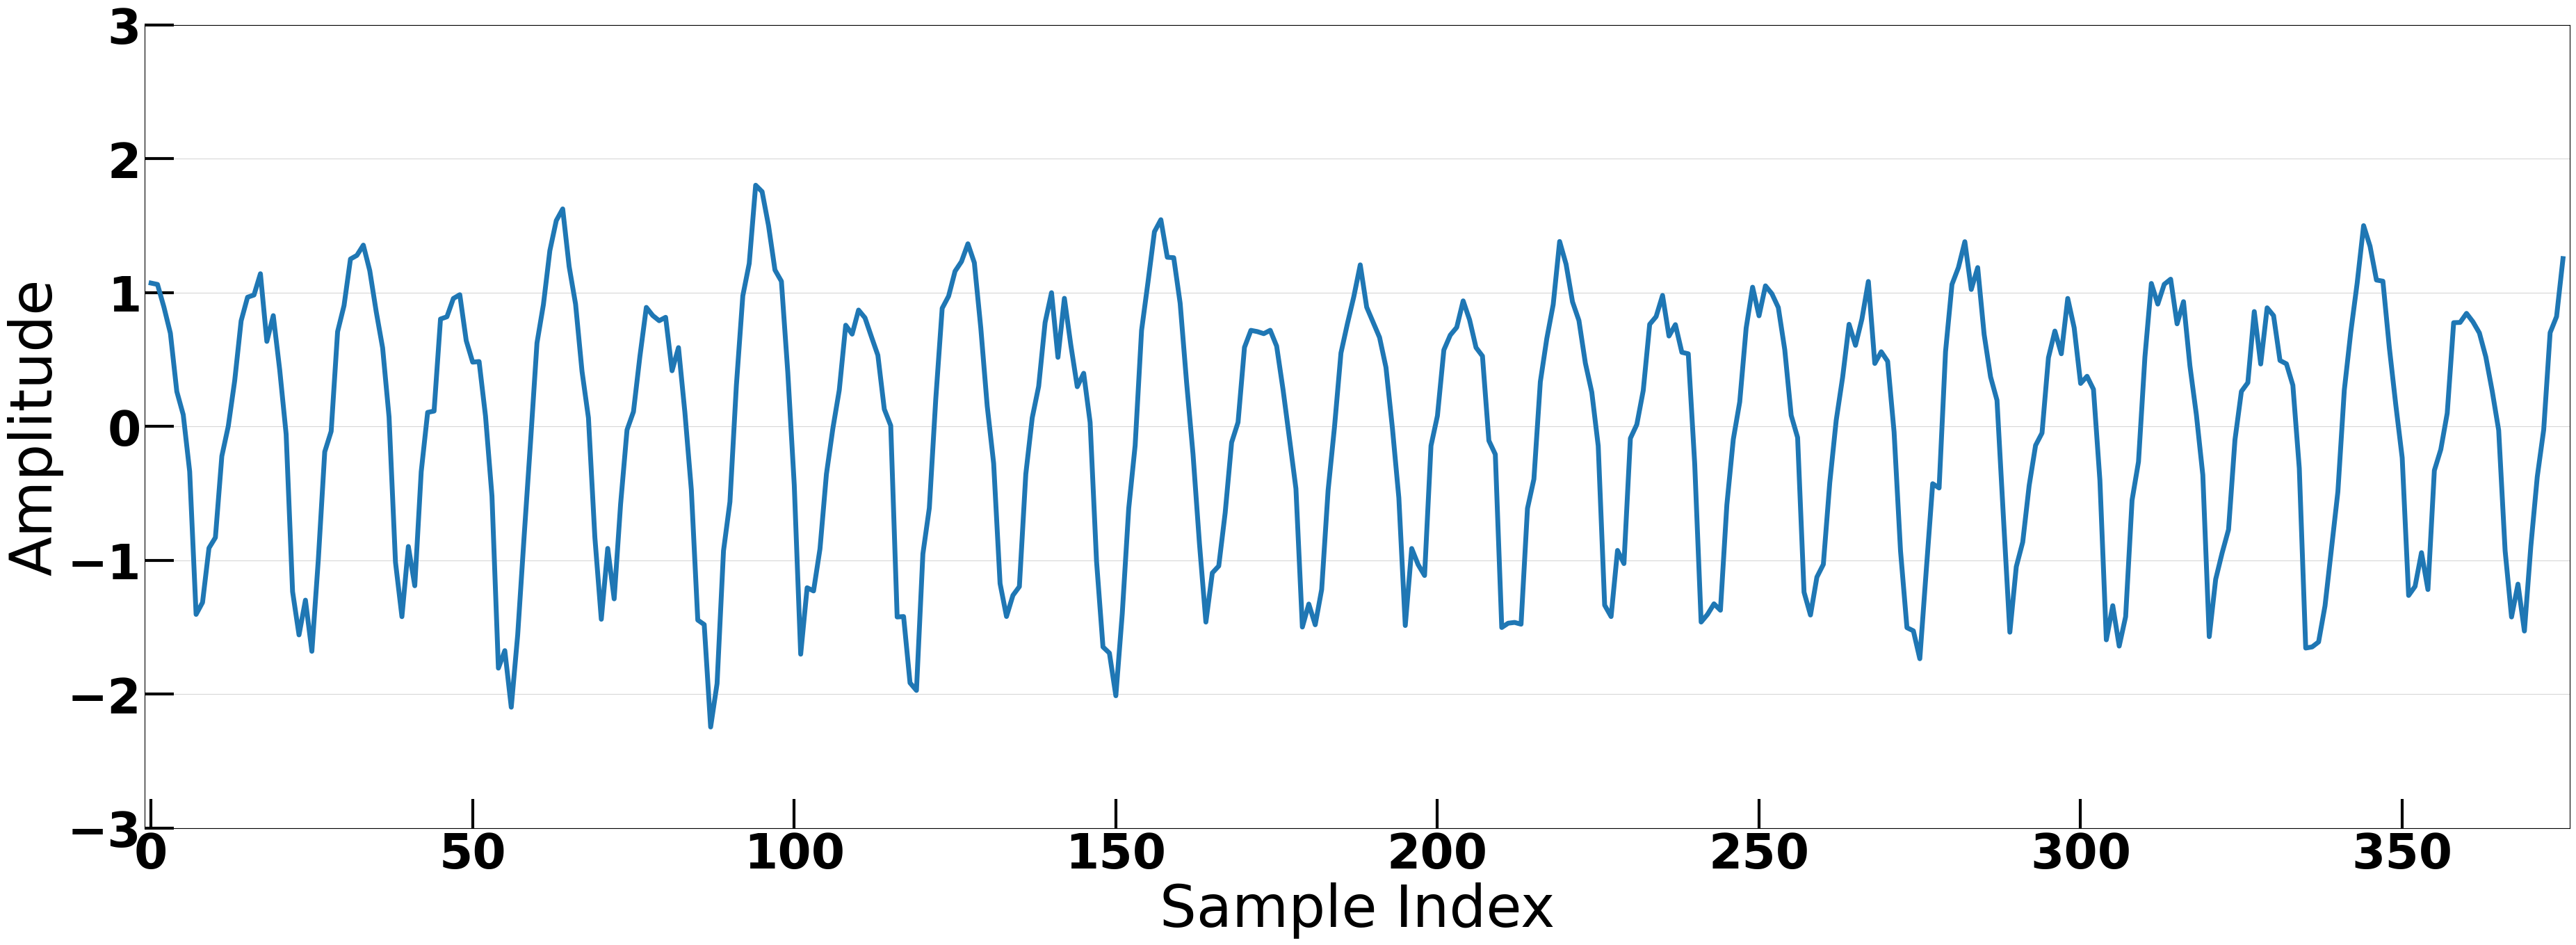

In [193]:
time_Signal = np.arange(signal_15.shape[0])
plt.plot(time_Signal, signal_15, label="", markersize=30)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.xlim([-1,len(signal_original)])
plt.ylim(-3,3)
#plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Full/" + "alpha_15.png", bbox_inches='tight')    
plt.show()
plt.close()

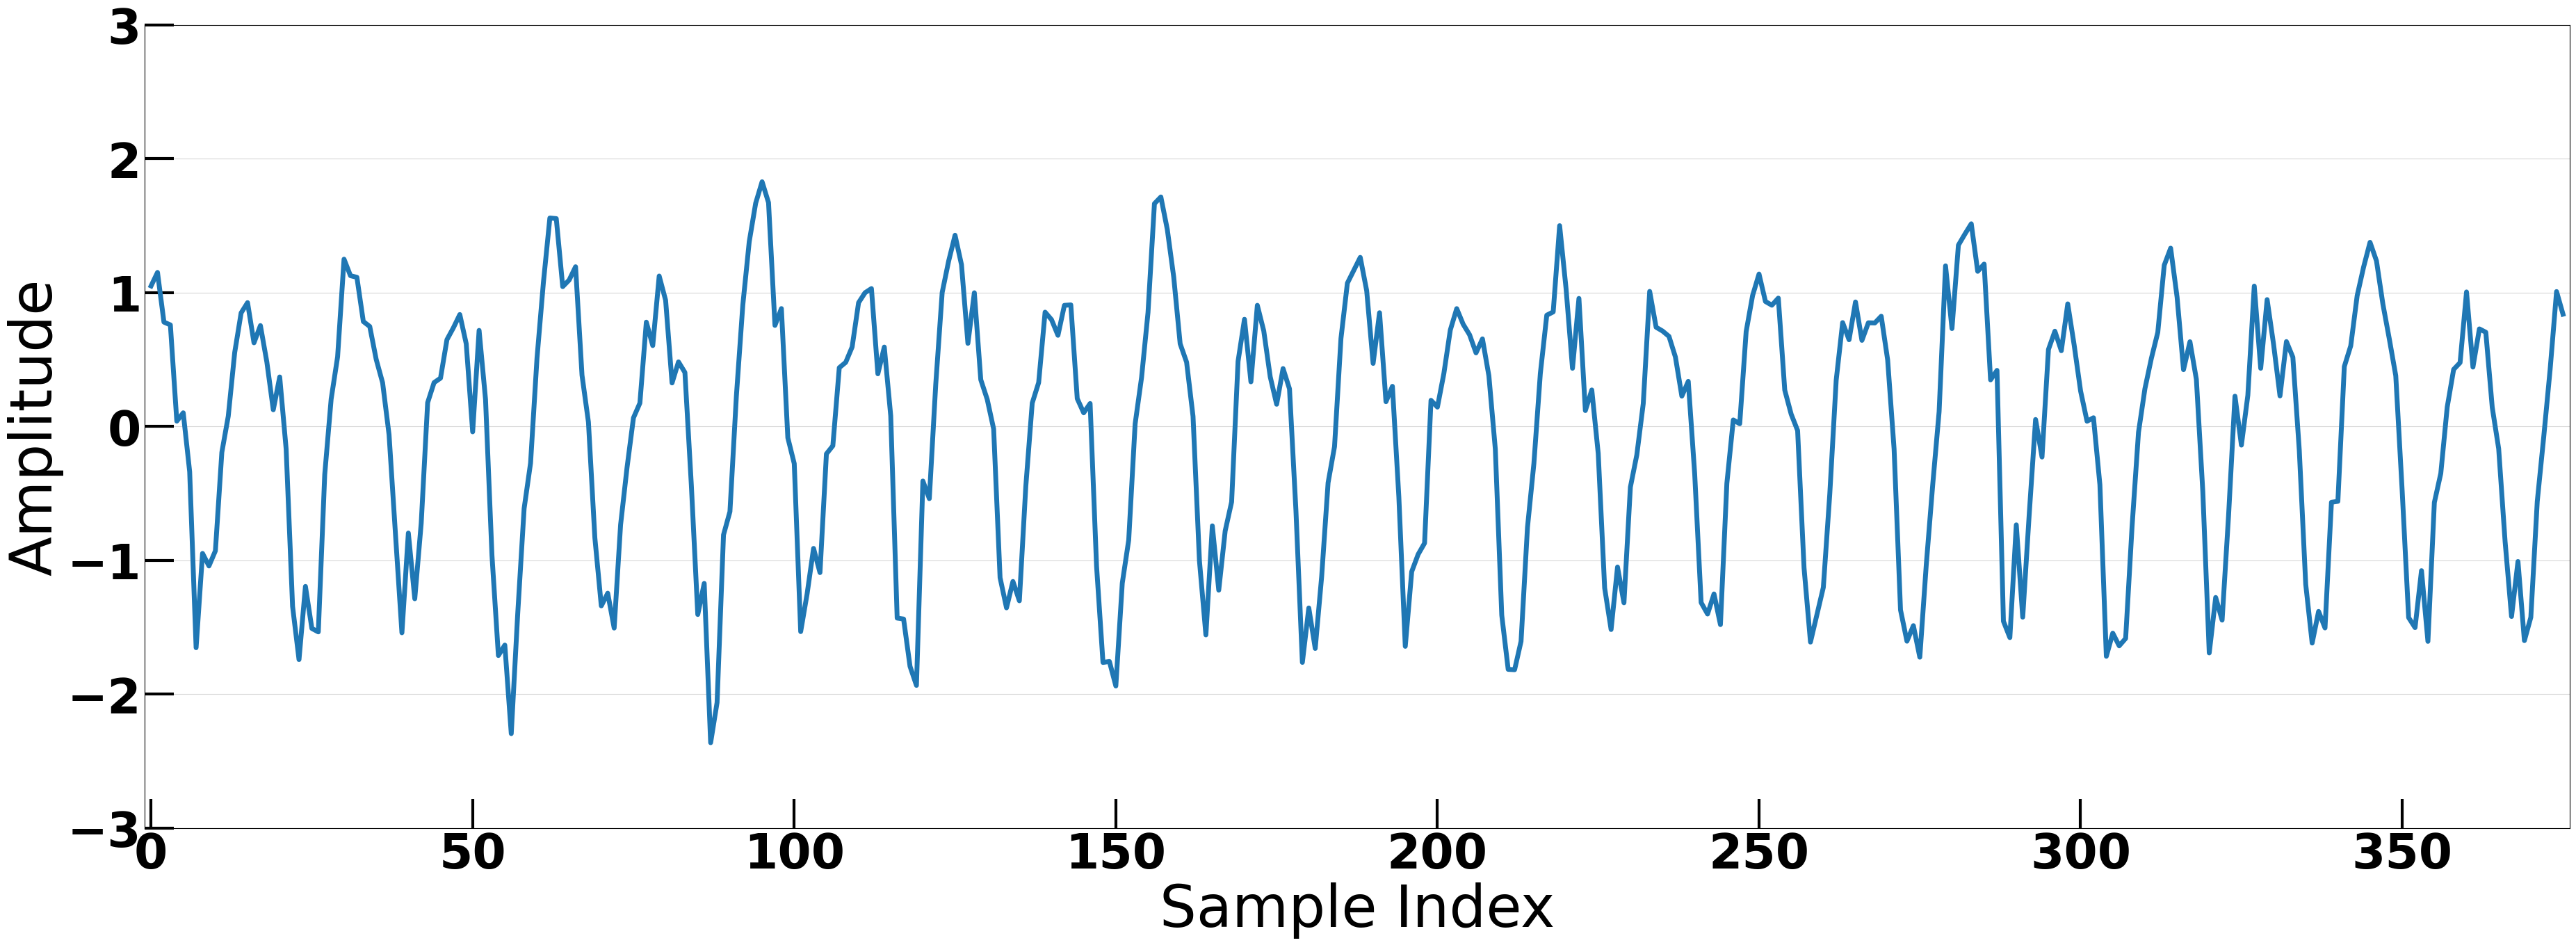

In [195]:
time_Signal = np.arange(signal_10.shape[0])
plt.plot(time_Signal, signal_10, label="", markersize=30)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.xlim([-1,len(signal_original)])
plt.ylim(-3,3)
#plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Full/" + "alpha_10.png", bbox_inches='tight')    
plt.show()
plt.close()

### MP

In [198]:
signal_original = alpha_MP[0]
signal_50 = alpha_SNR_50_MP[0]
signal_40 = alpha_SNR_40_MP[0]
signal_30 = alpha_SNR_30_MP[0]
signal_25 = alpha_SNR_25_MP[0]
signal_20 = alpha_SNR_20_MP[0]
signal_15 = alpha_SNR_15_MP[0]
signal_10 = alpha_SNR_10_MP[0]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


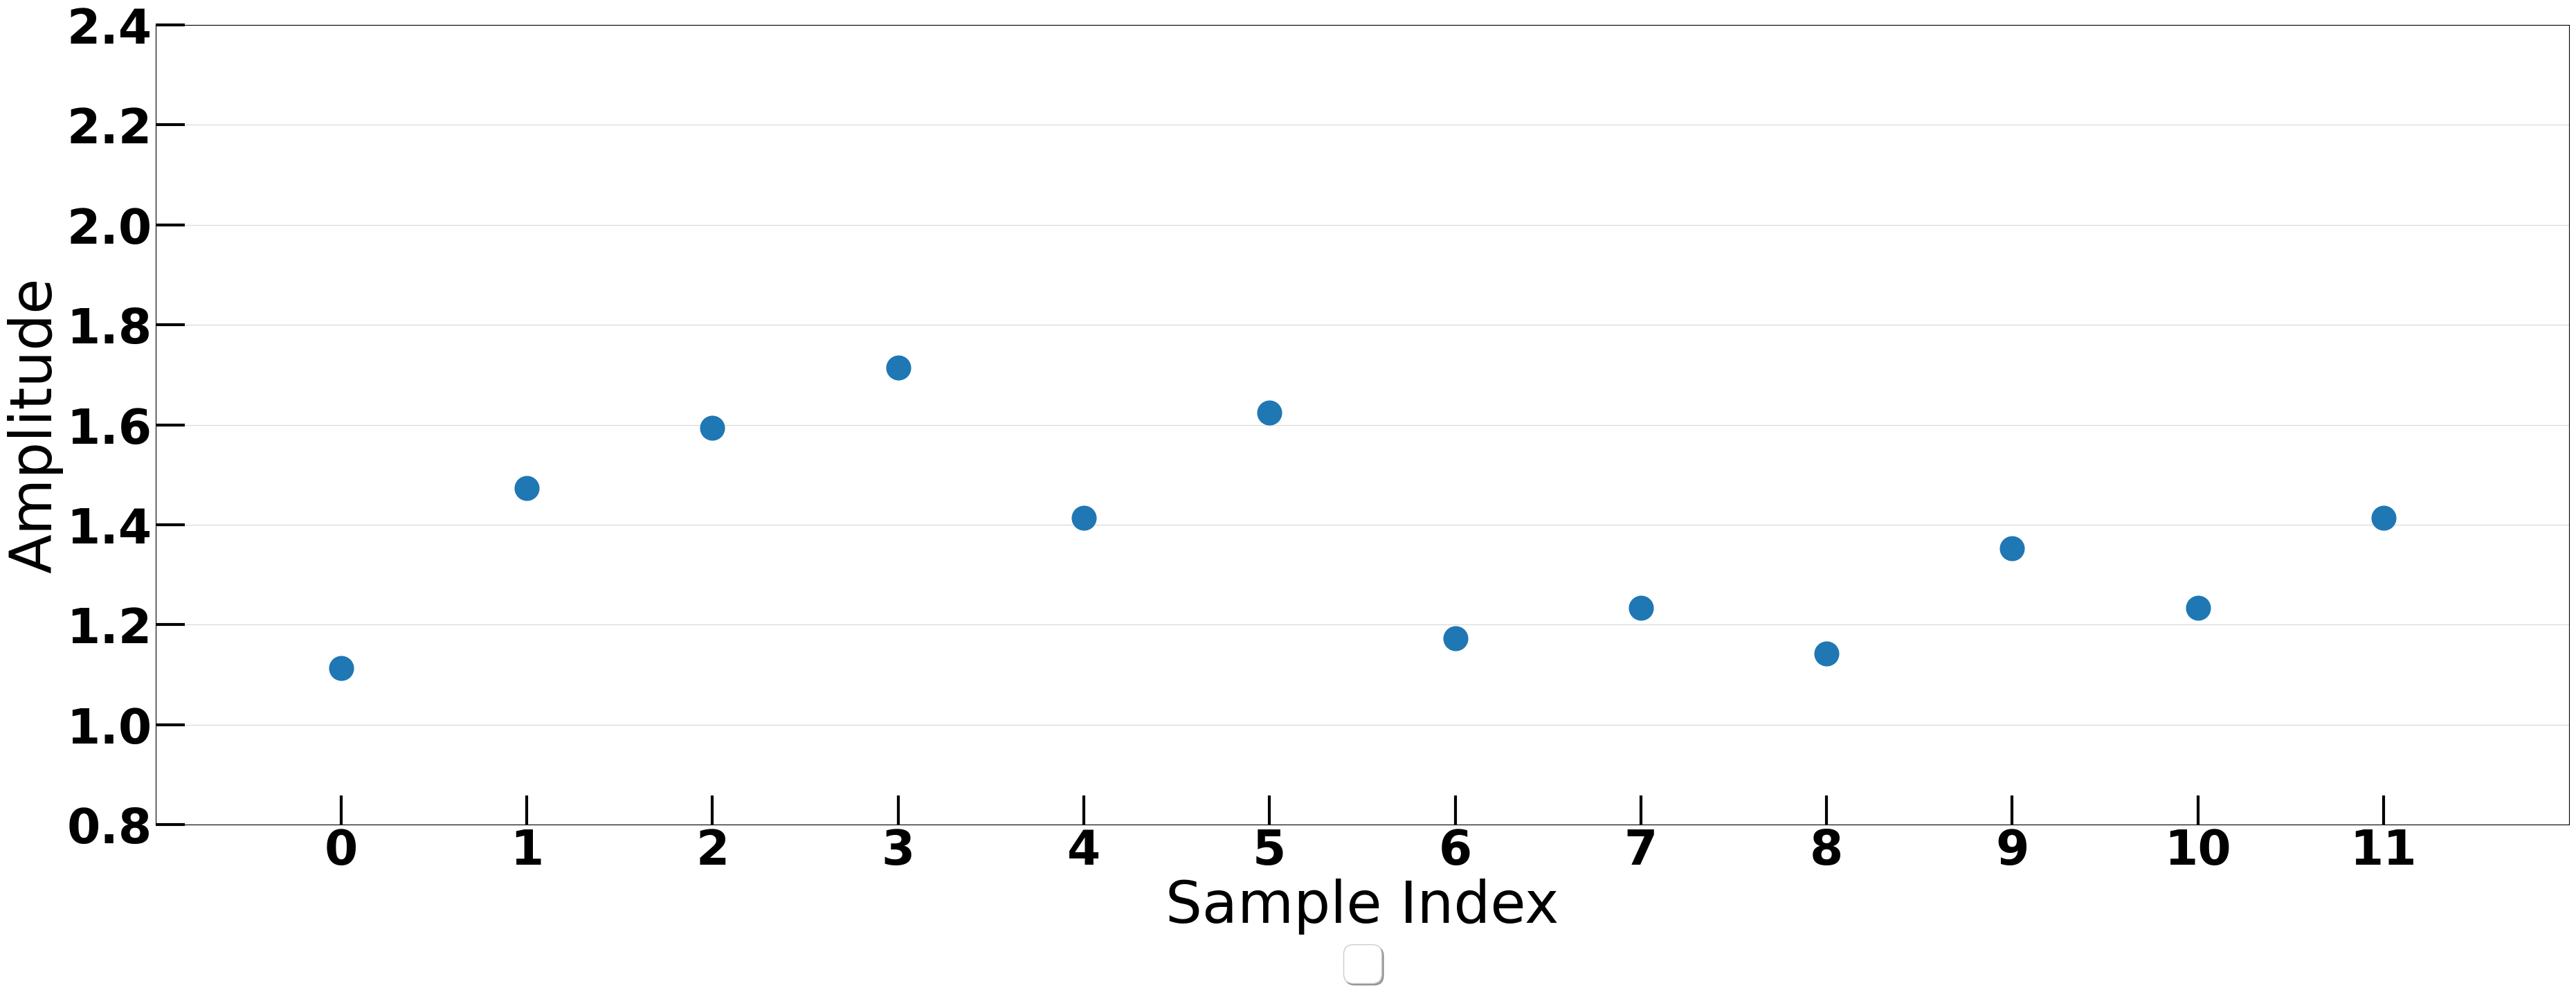

In [199]:
time_Signal = np.arange(signal_original.shape[0])
plt.plot(time_Signal, signal_original, 'o', label="", markersize=25)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(signal_original)])
plt.ylim(.8,2.4)
plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Peaks/" + "alpha_No_Noise_peaks.png", bbox_inches='tight')
plt.show()
plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


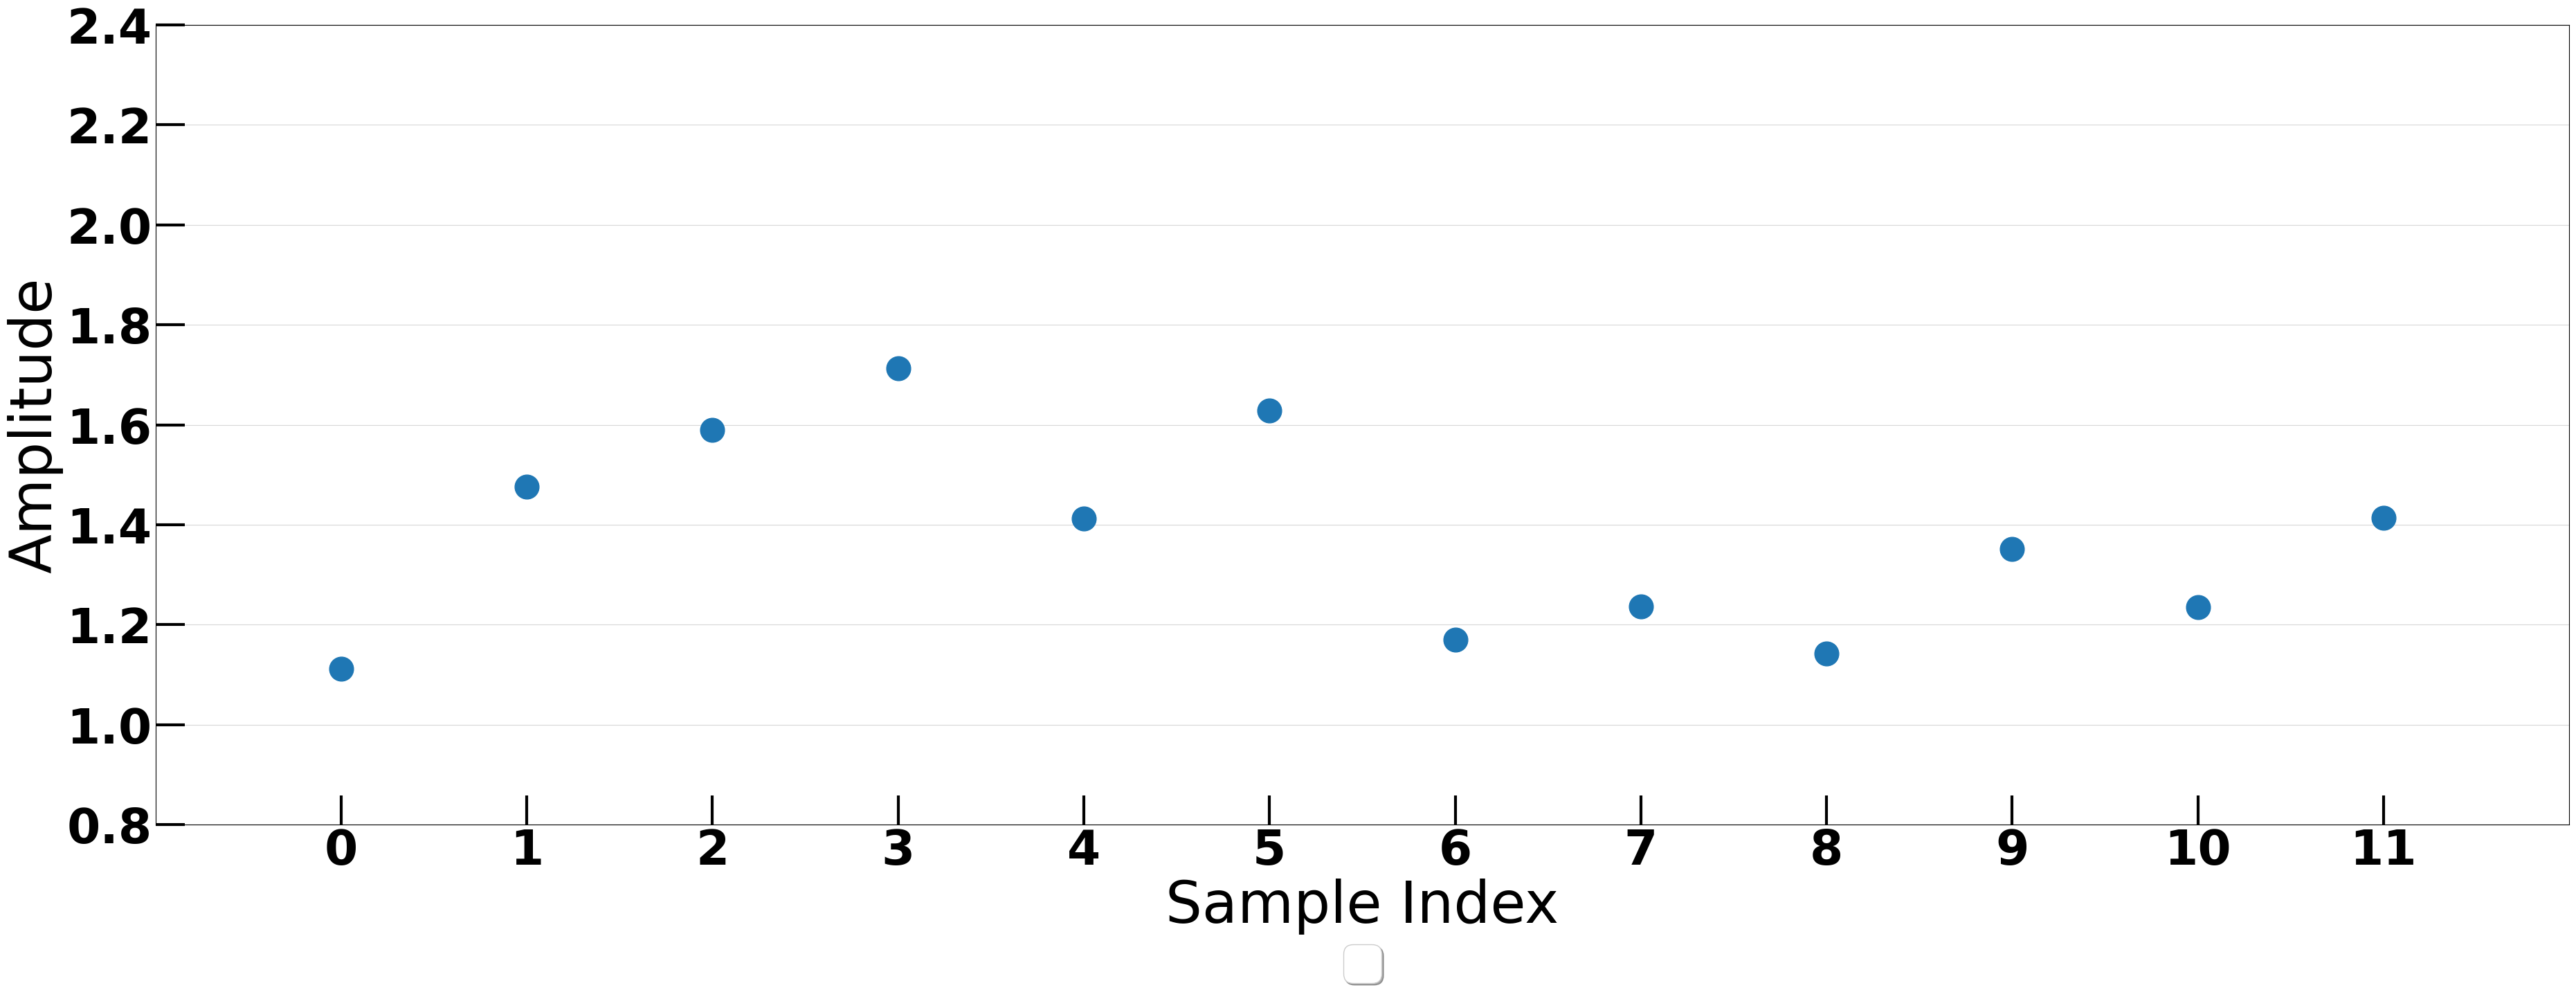

In [200]:
time_Signal = np.arange(signal_50.shape[0])
plt.plot(time_Signal, signal_50, 'o', label="", markersize=25)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(signal_original)])
plt.ylim(.8,2.4)
plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Peaks/" + "alpha_50_peaks.png", bbox_inches='tight')
plt.show()
plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


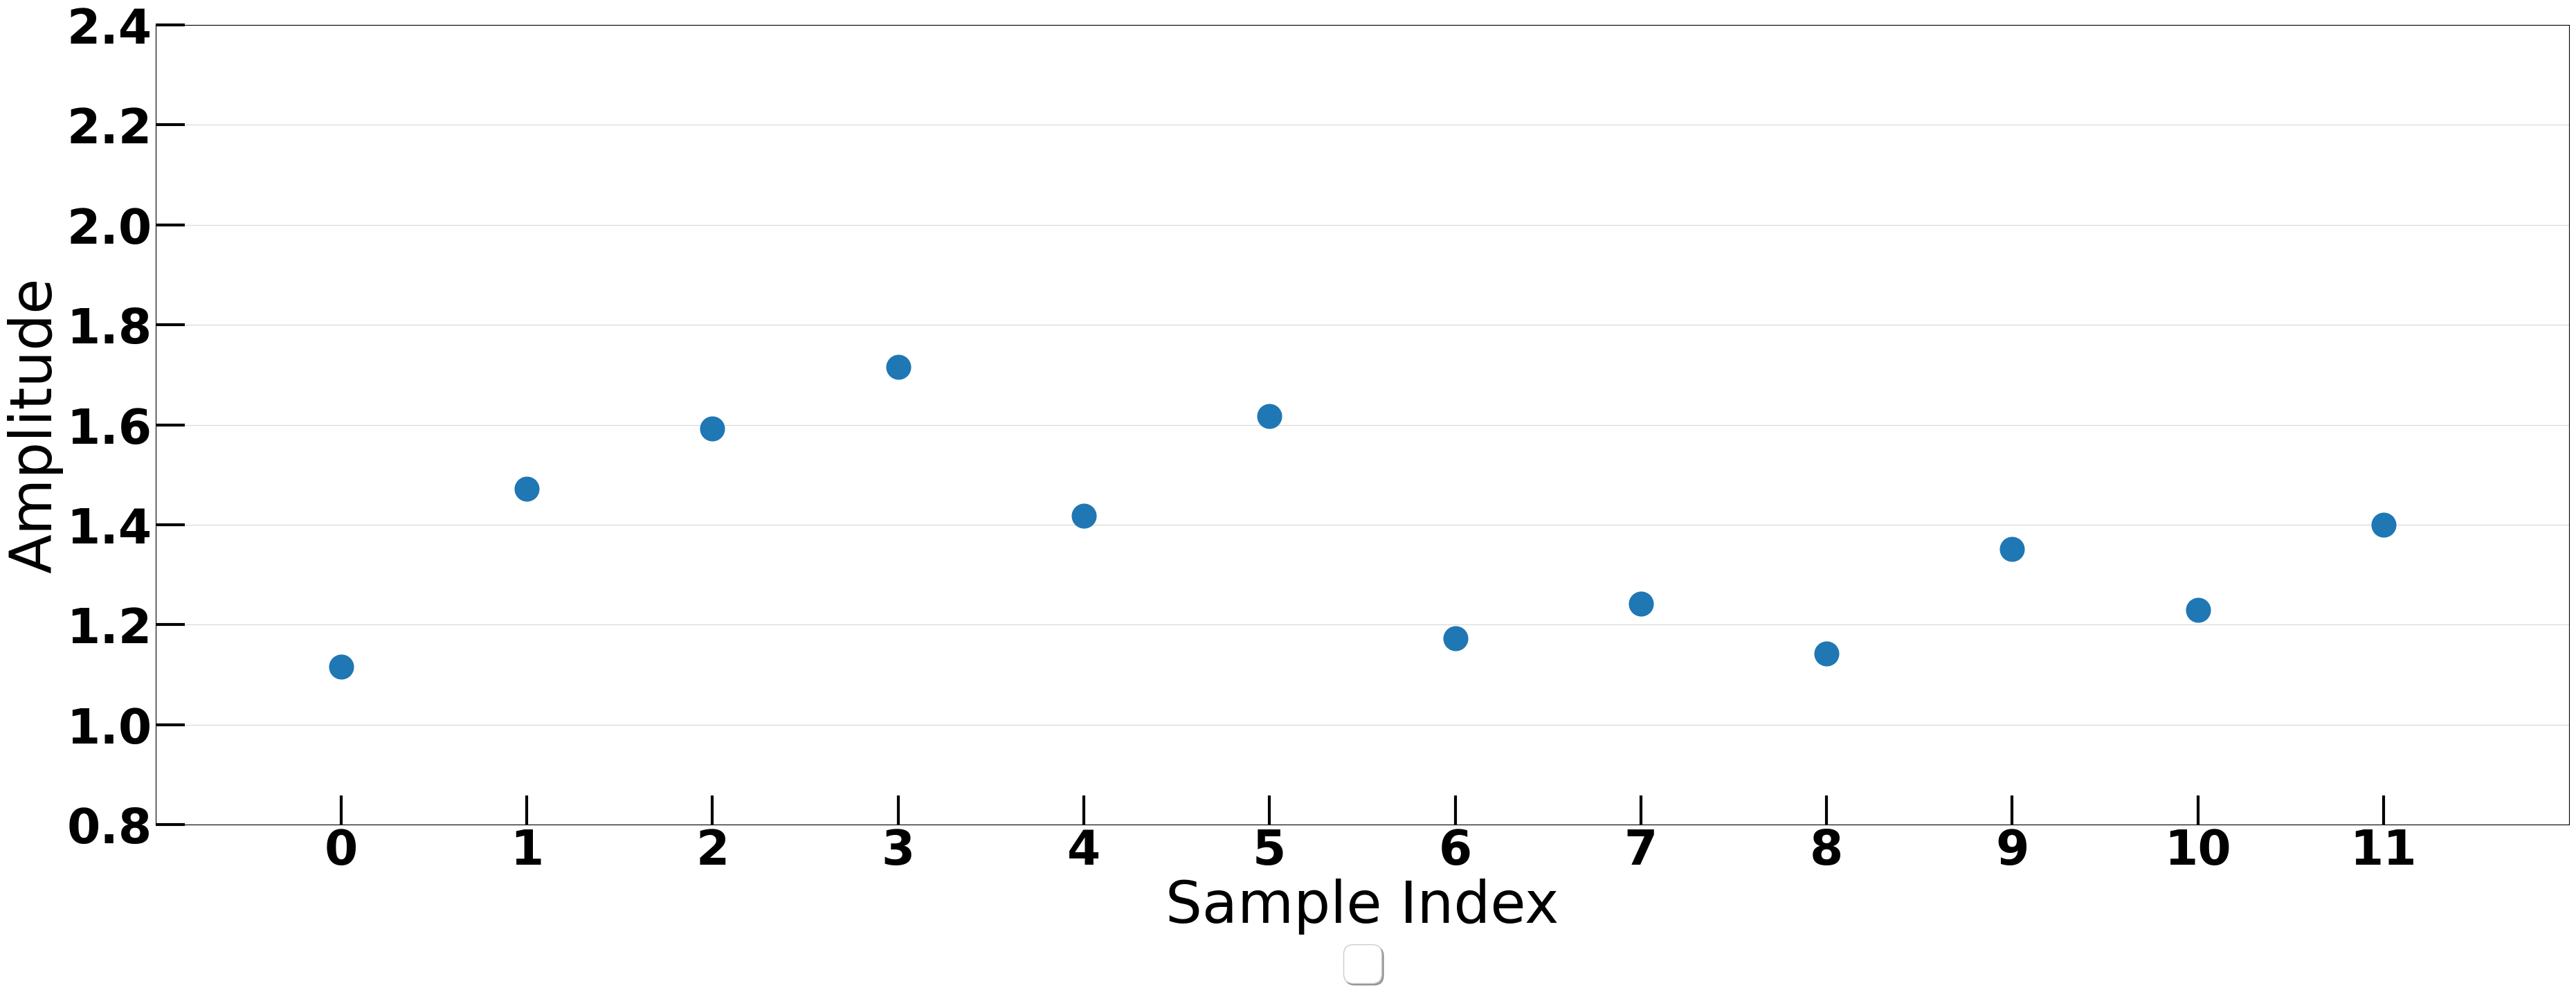

In [201]:
time_Signal = np.arange(signal_40.shape[0])
plt.plot(time_Signal, signal_40, 'o', label="", markersize=25)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(signal_original)])
plt.ylim(.8,2.4)
plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Peaks/" + "alpha_40_peaks.png", bbox_inches='tight')
plt.show()
plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


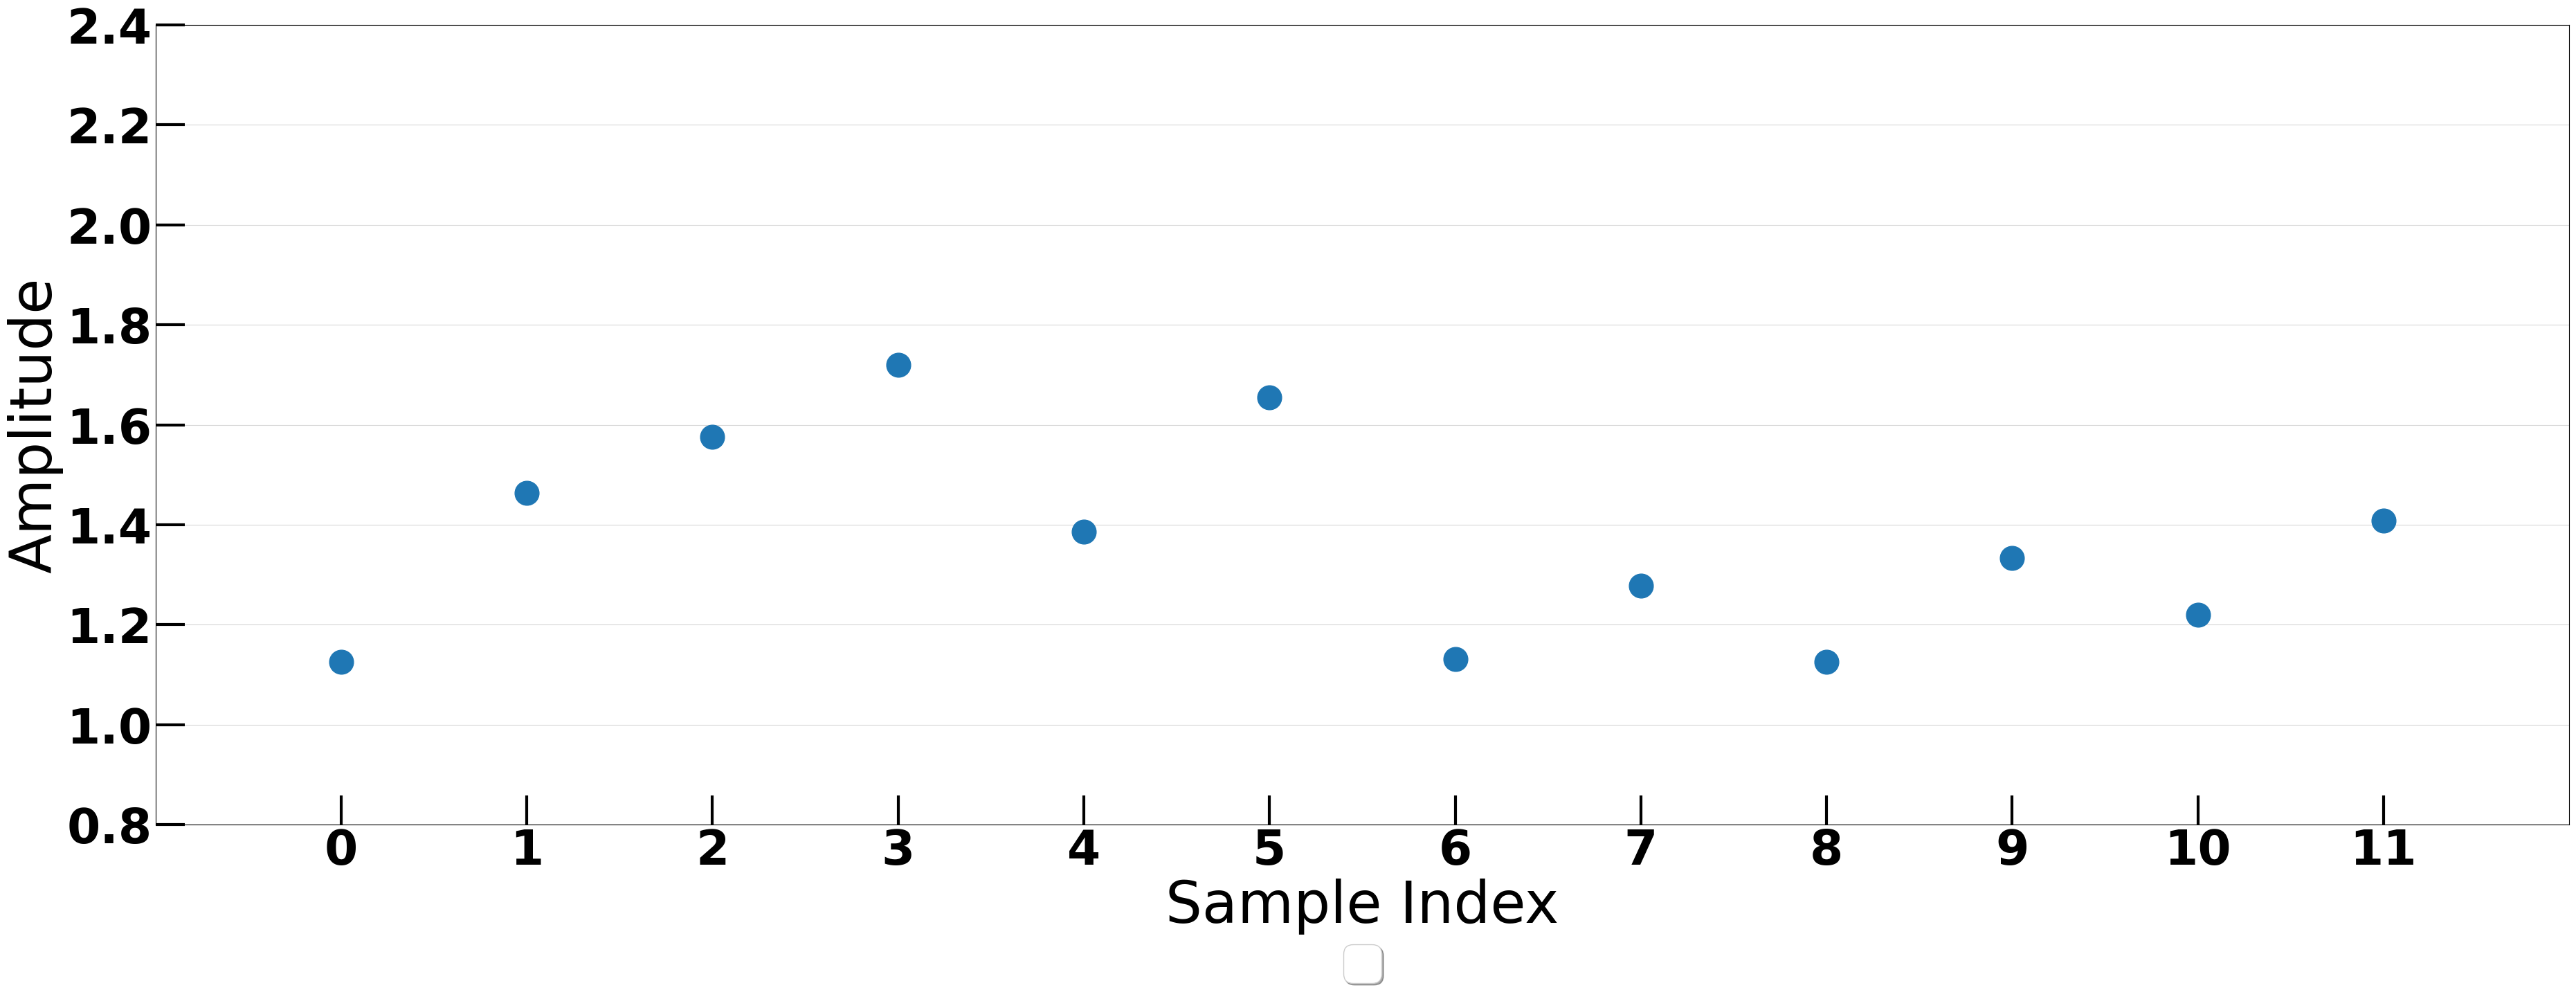

In [202]:
time_Signal = np.arange(signal_30.shape[0])
plt.plot(time_Signal, signal_30, 'o', label="", markersize=25)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(signal_original)])
plt.ylim(.8,2.4)
plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Peaks/" + "alpha_30_peaks.png", bbox_inches='tight')
plt.show()
plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


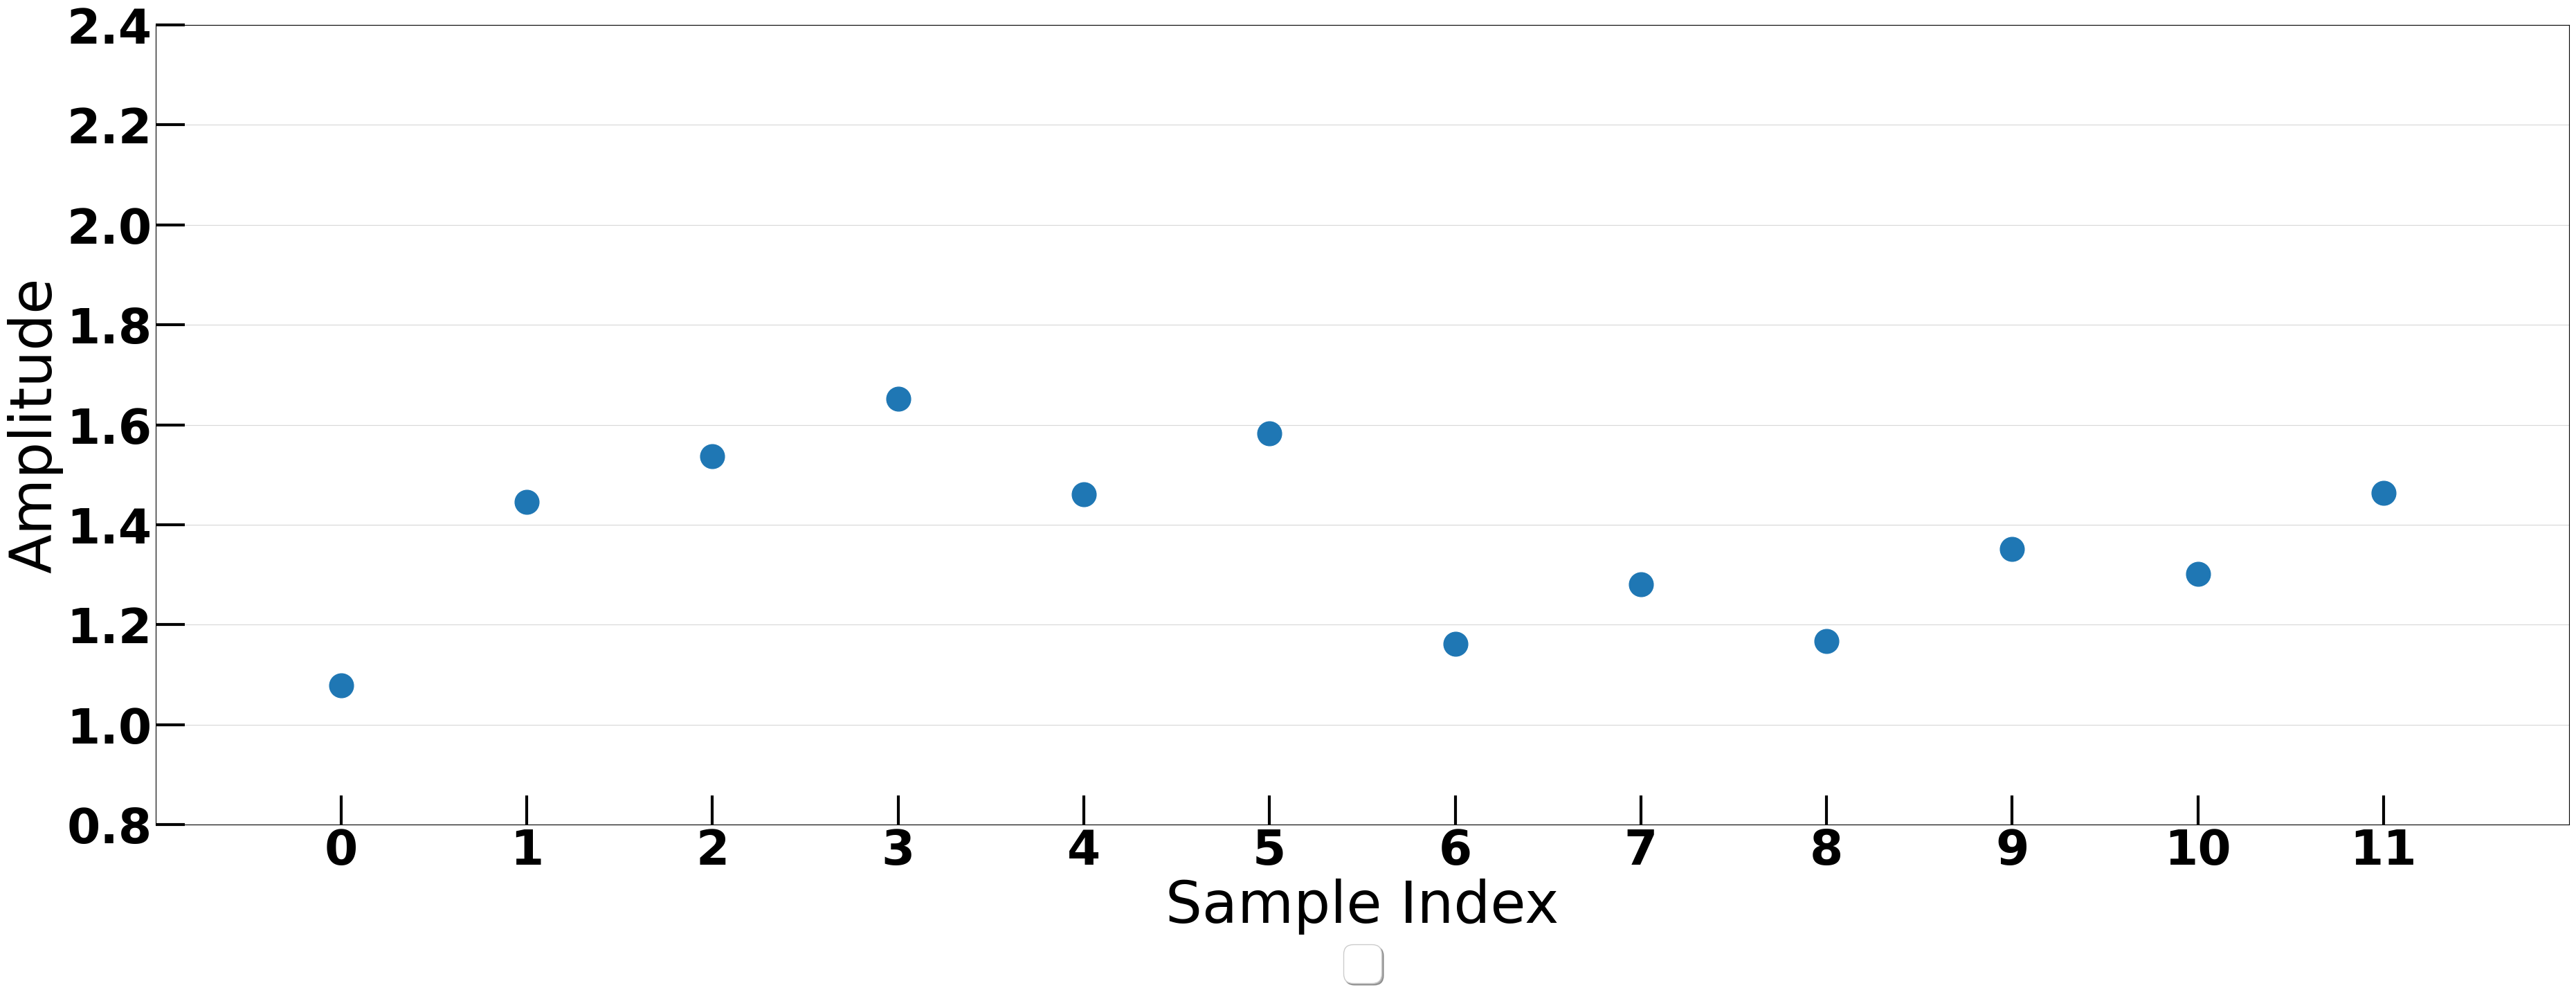

In [203]:
time_Signal = np.arange(signal_25.shape[0])
plt.plot(time_Signal, signal_25, 'o', label="", markersize=25)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(signal_original)])
plt.ylim(.8,2.4)
plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Peaks/" + "alpha_25_peaks.png", bbox_inches='tight')
plt.show()
plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


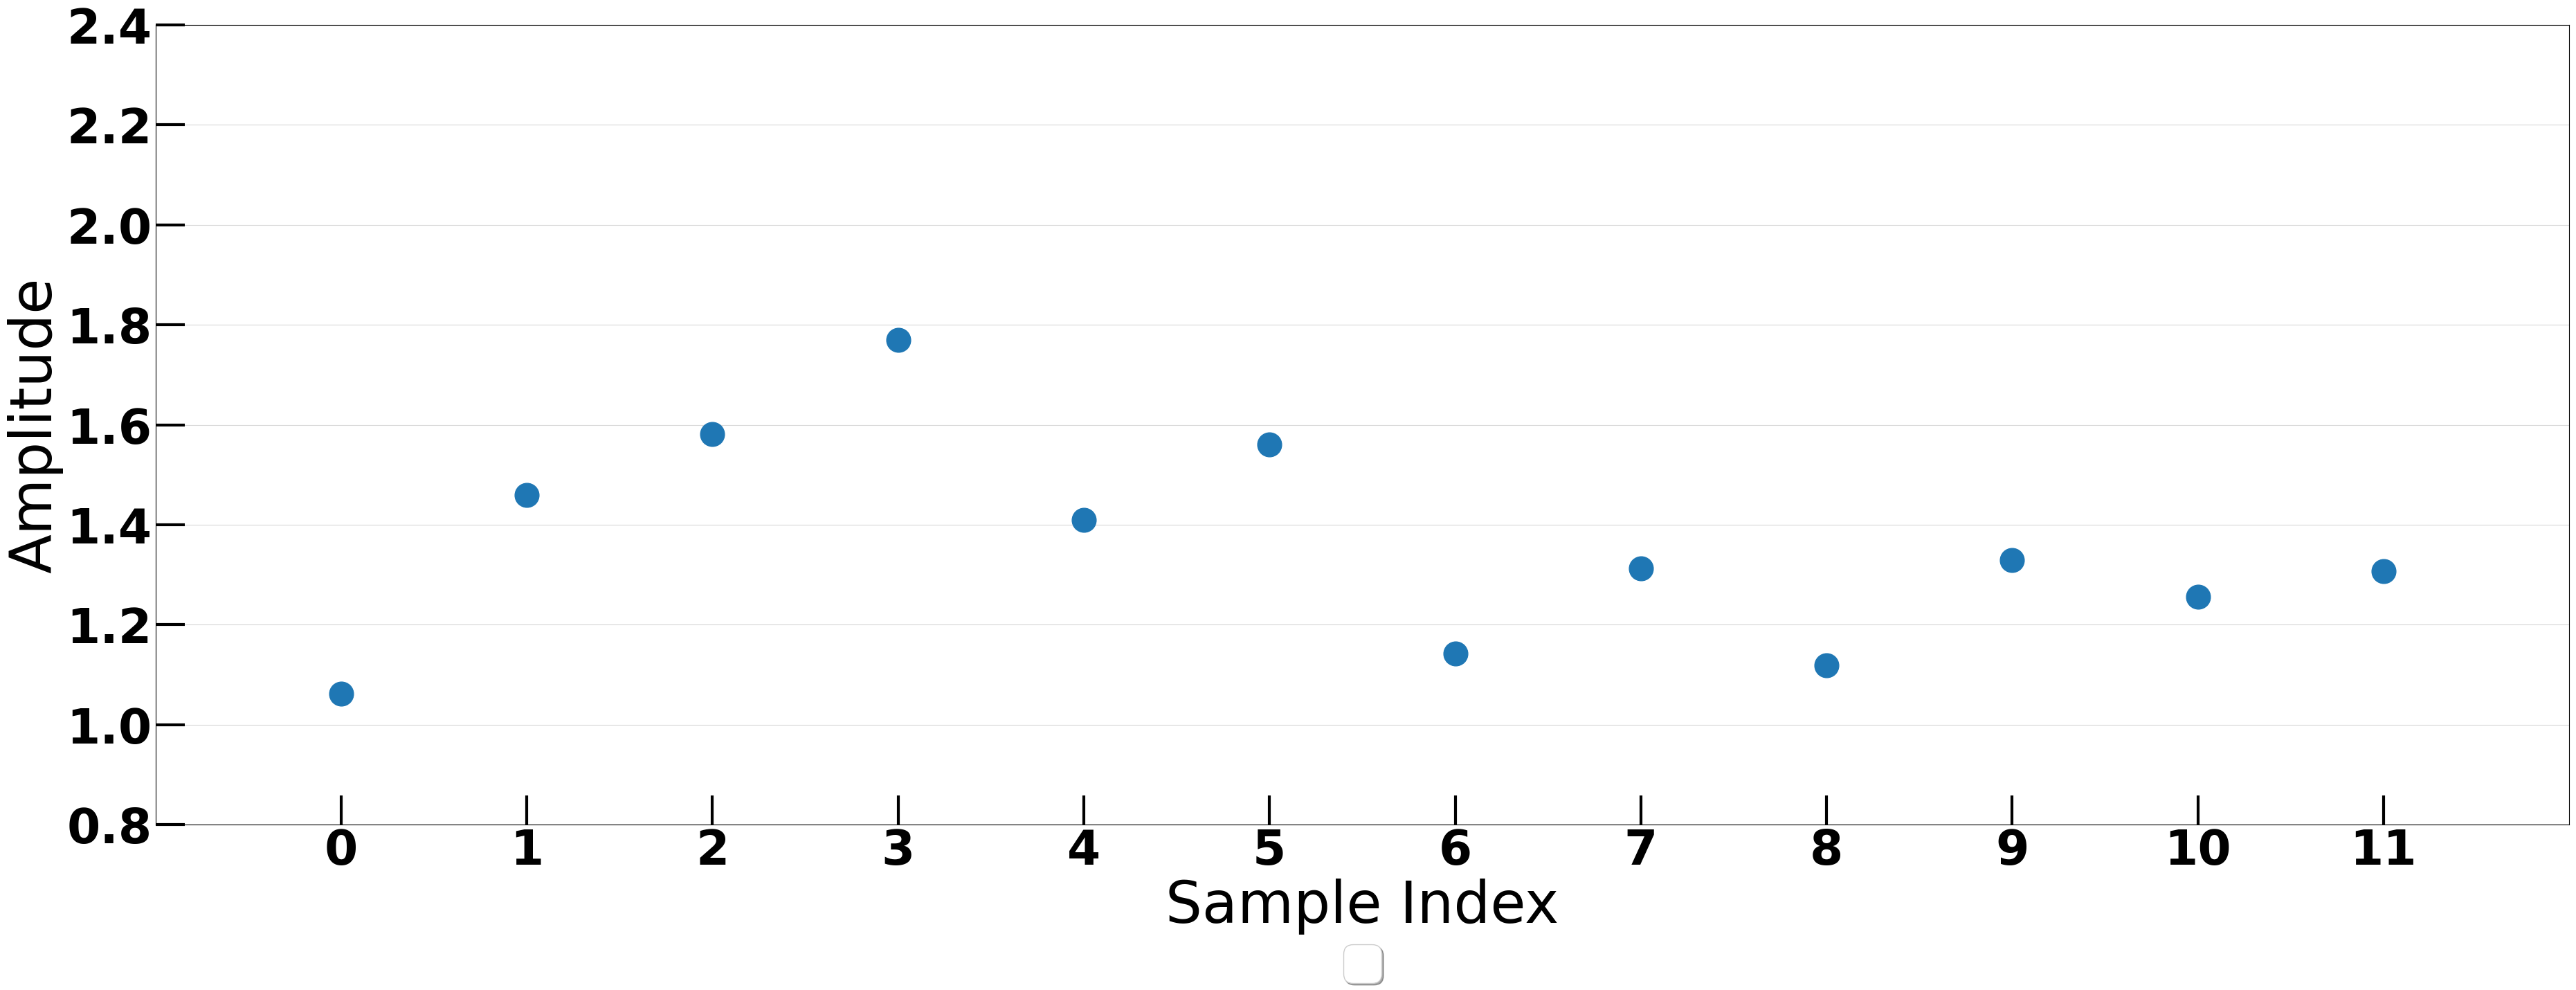

In [204]:
time_Signal = np.arange(signal_20.shape[0])
plt.plot(time_Signal, signal_20, 'o', label="", markersize=25)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(signal_original)])
plt.ylim(.8,2.4)
plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Peaks/" + "alpha_20_peaks.png", bbox_inches='tight')
plt.show()
plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


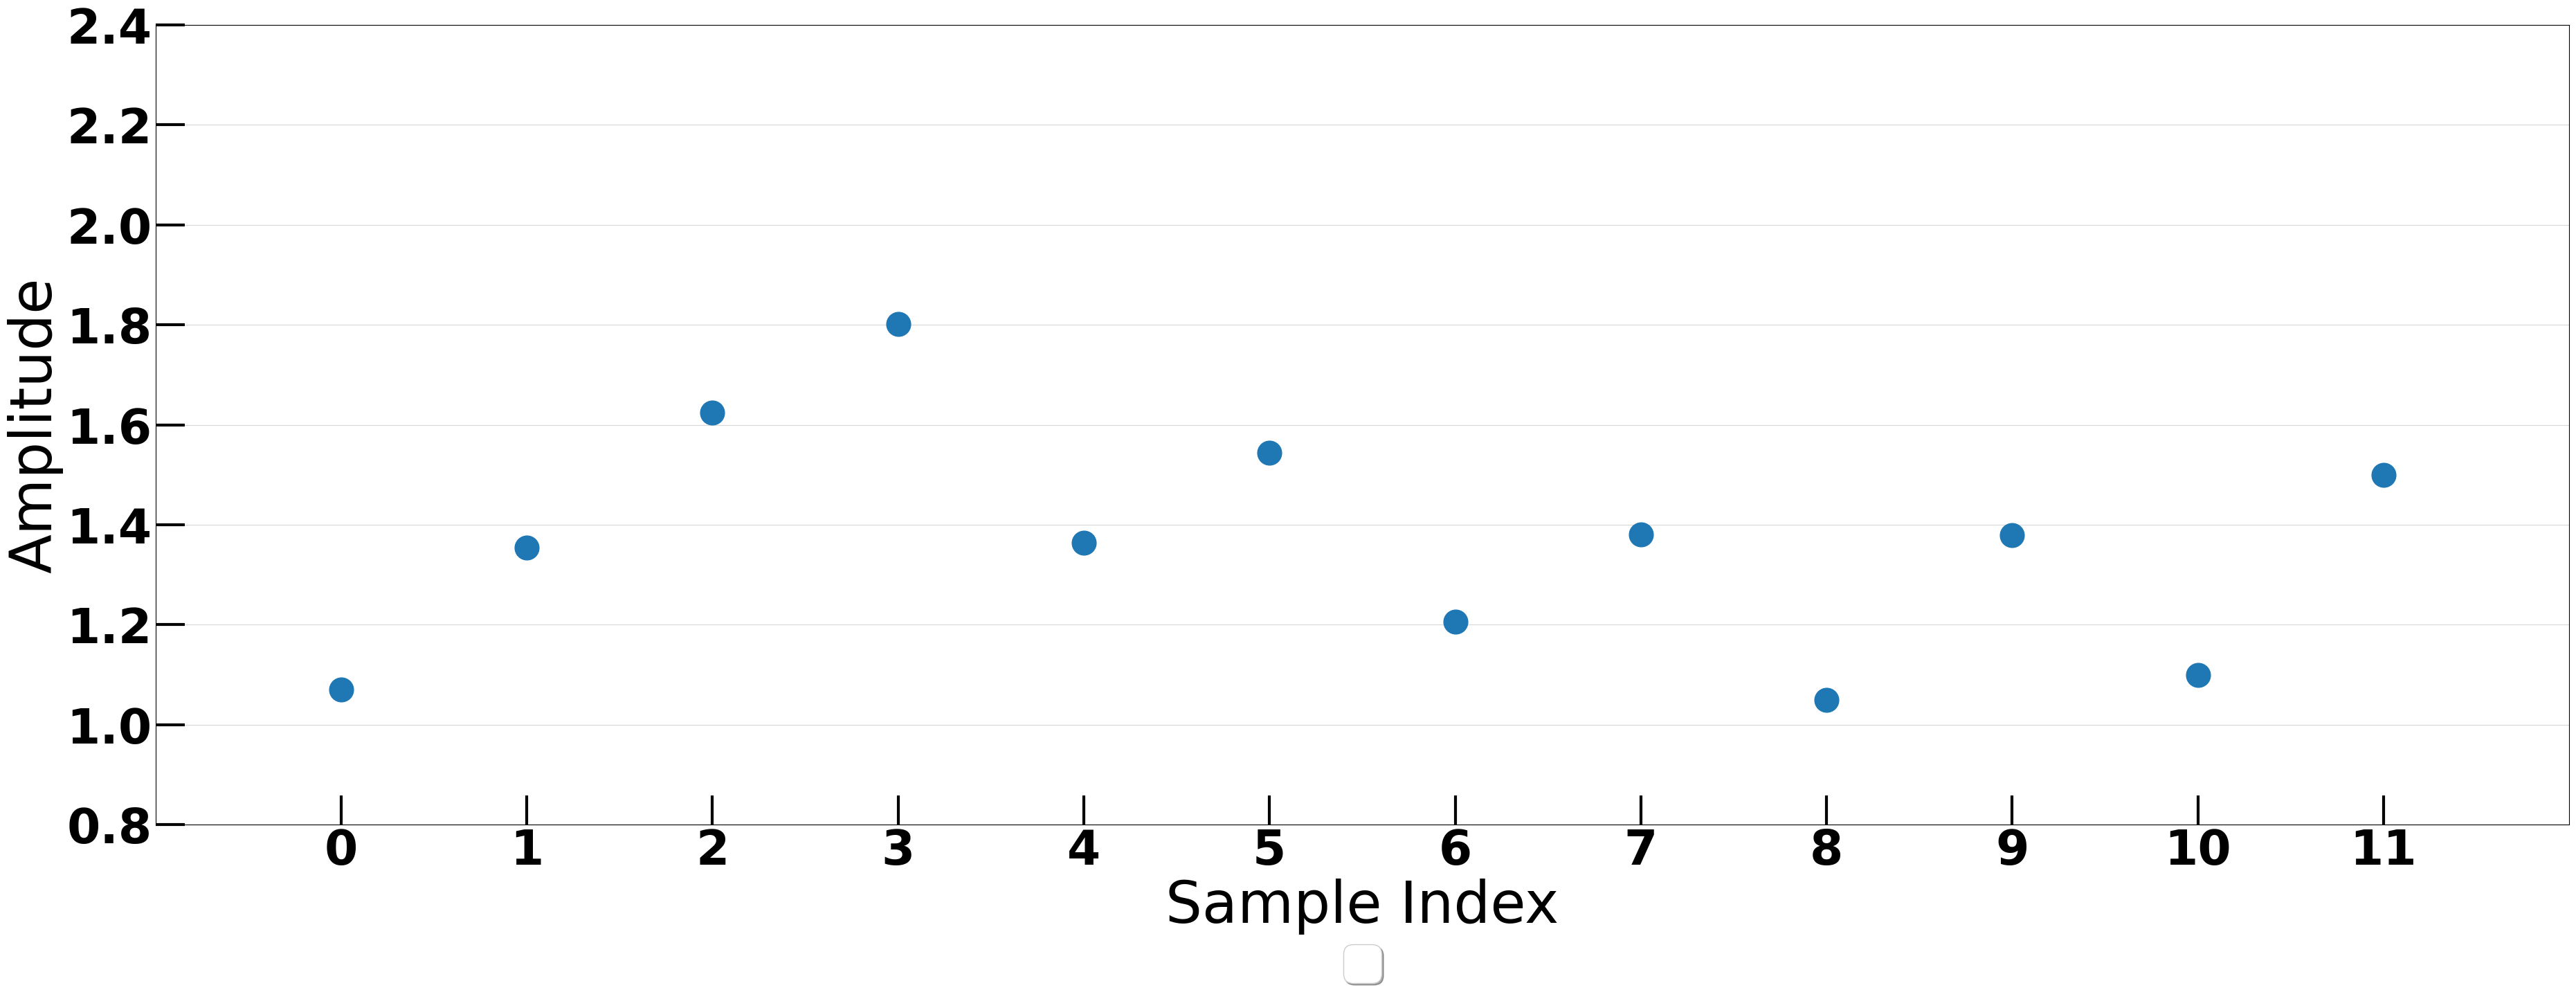

In [205]:
time_Signal = np.arange(signal_15.shape[0])
plt.plot(time_Signal, signal_15, 'o', label="", markersize=25)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(signal_original)])
plt.ylim(.8,2.4)
plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Peaks/" + "alpha_15_peaks.png", bbox_inches='tight')
plt.show()
plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


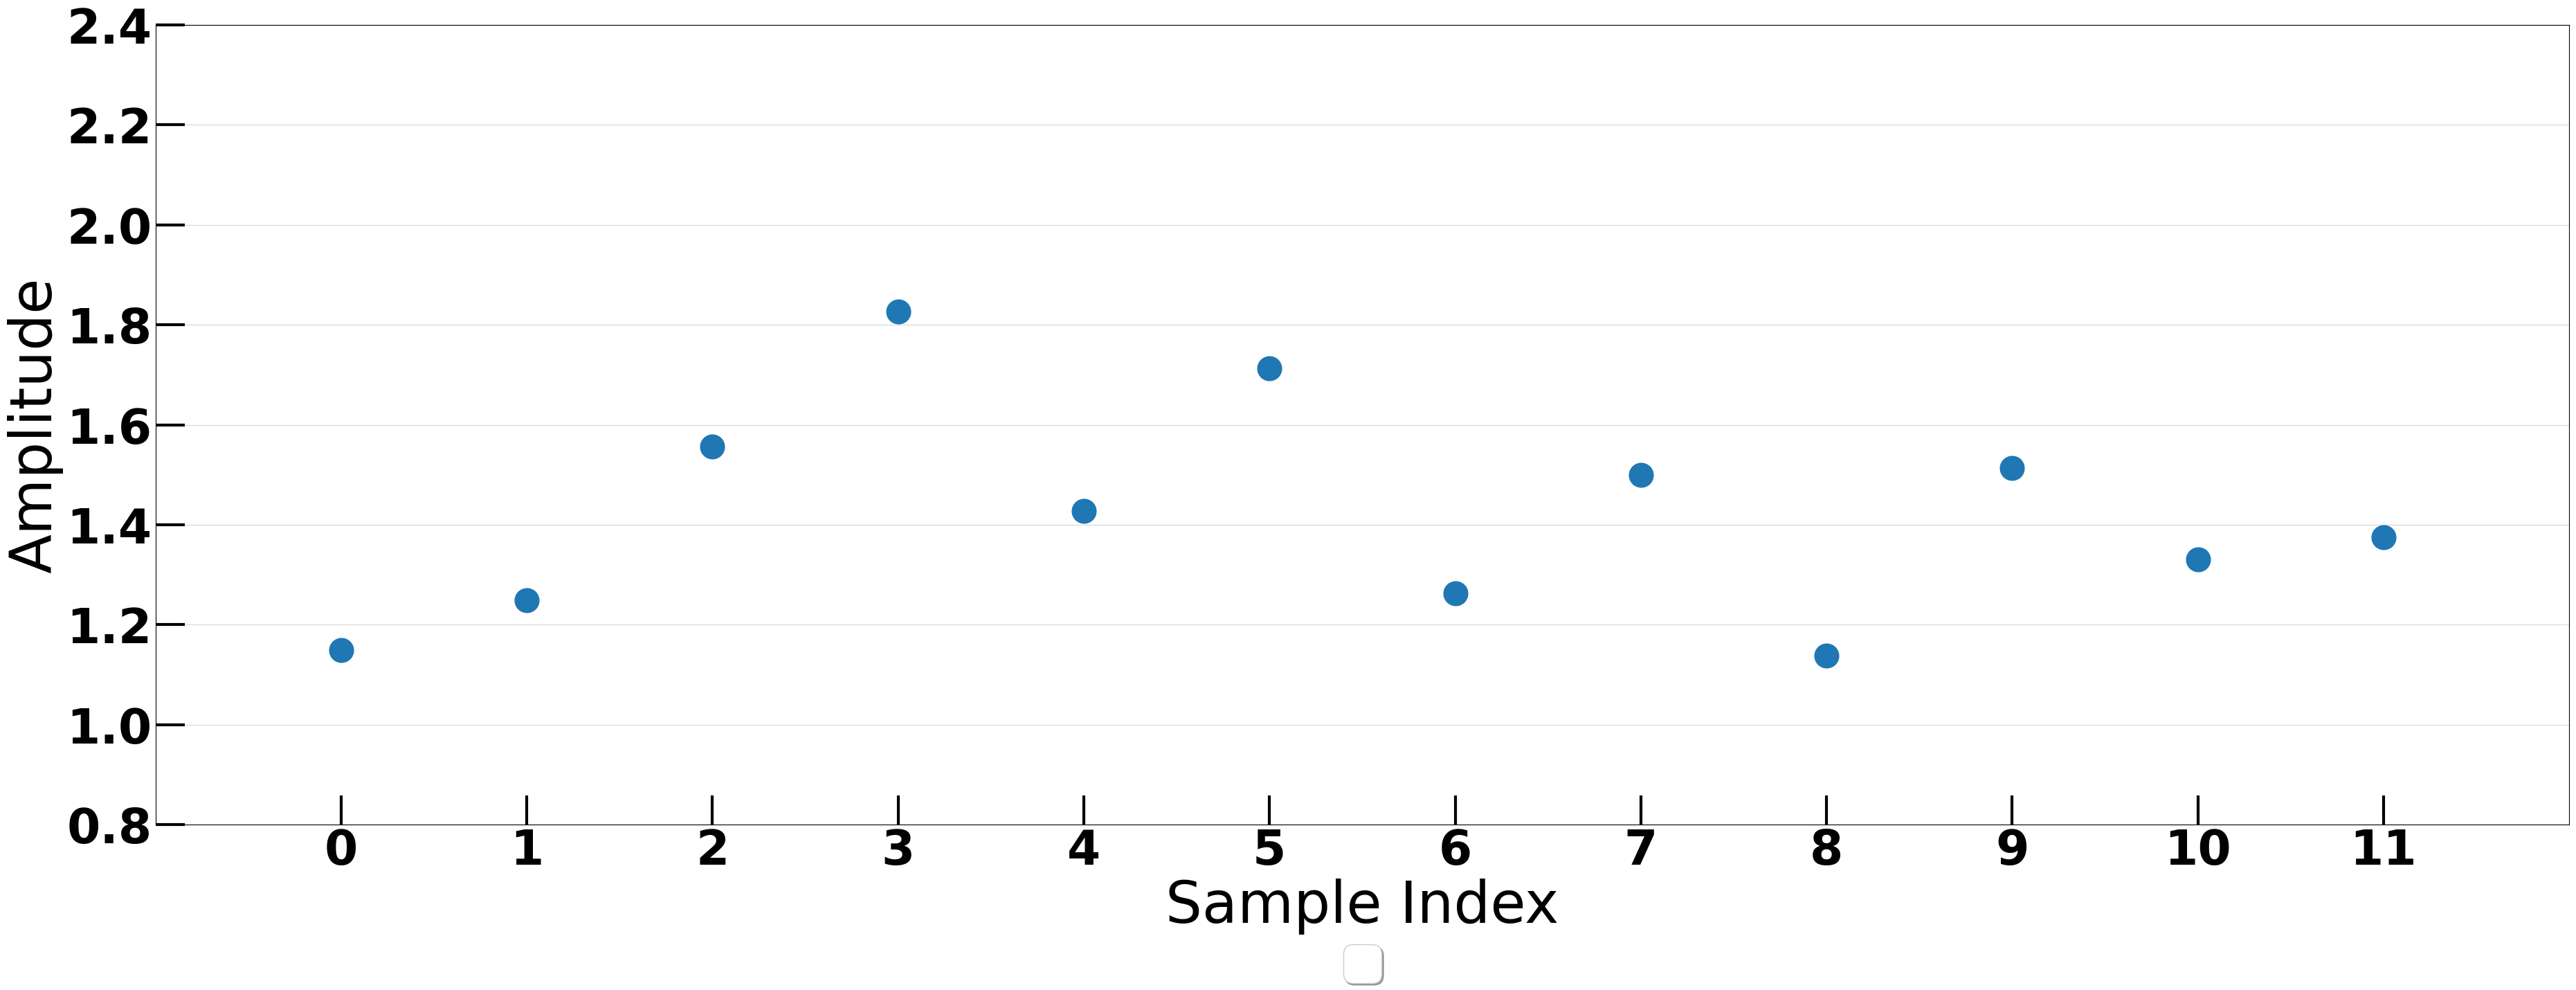

In [207]:
time_Signal = np.arange(signal_10.shape[0])
plt.plot(time_Signal, signal_10, 'o', label="", markersize=25)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([-1,len(signal_original)])
plt.ylim(.8,2.4)
plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("./Graphs/12/Signals/Peaks/" + "alpha_10_peaks.png", bbox_inches='tight')
plt.show()
plt.close()

# Save

In [26]:
np.save("./Datasets/Numpy/WGN/alpha_SNR_50_MP.npy", alpha_SNR_50_MP)
np.save("./Datasets/Numpy/WGN/alpha_SNR_40_MP.npy", alpha_SNR_40_MP)
np.save("./Datasets/Numpy/WGN/alpha_SNR_30_MP.npy", alpha_SNR_30_MP)
np.save("./Datasets/Numpy/WGN/alpha_SNR_25_MP.npy", alpha_SNR_25_MP)
np.save("./Datasets/Numpy/WGN/alpha_SNR_20_MP.npy", alpha_SNR_20_MP)
np.save("./Datasets/Numpy/WGN/alpha_SNR_15_MP.npy", alpha_SNR_15_MP)
np.save("./Datasets/Numpy/WGN/alpha_SNR_10_MP.npy", alpha_SNR_10_MP)

np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_50_MP.npy", alpha_sub_SNR_50_MP)
np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_40_MP.npy", alpha_sub_SNR_40_MP)
np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_30_MP.npy", alpha_sub_SNR_30_MP)
np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_25_MP.npy", alpha_sub_SNR_25_MP)
np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_20_MP.npy", alpha_sub_SNR_20_MP)
np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_15_MP.npy", alpha_sub_SNR_15_MP)
np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_10_MP.npy", alpha_sub_SNR_10_MP)

In [28]:
np.save("./Datasets/Numpy/WGN/alpha_SNR_50_Full.npy", alpha_SNR_50)
np.save("./Datasets/Numpy/WGN/alpha_SNR_40_Full.npy", alpha_SNR_40)
np.save("./Datasets/Numpy/WGN/alpha_SNR_30_Full.npy", alpha_SNR_30)
np.save("./Datasets/Numpy/WGN/alpha_SNR_25_Full.npy", alpha_SNR_25)
np.save("./Datasets/Numpy/WGN/alpha_SNR_20_Full.npy", alpha_SNR_20)
np.save("./Datasets/Numpy/WGN/alpha_SNR_15_Full.npy", alpha_SNR_15)
np.save("./Datasets/Numpy/WGN/alpha_SNR_10_Full.npy", alpha_SNR_10)

np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_50_Full.npy", alpha_sub_SNR_50)
np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_40_Full.npy", alpha_sub_SNR_40)
np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_30_Full.npy", alpha_sub_SNR_30)
np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_25_Full.npy", alpha_sub_SNR_25)
np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_20_Full.npy", alpha_sub_SNR_20)
np.save("./Datasets/Numpy/WGN/alpha_sub_SNR_15_Full.npy", alpha_sub_SNR_15)

# Load

In [22]:
alpha_SNR_50 = np.load("./Datasets/Numpy/WGN/alpha_SNR_50_Full.npy", allow_pickle=True)
alpha_SNR_40 = np.load("./Datasets/Numpy/WGN/alpha_SNR_40_Full.npy", allow_pickle=True)
alpha_SNR_30 = np.load("./Datasets/Numpy/WGN/alpha_SNR_30_Full.npy", allow_pickle=True)
alpha_SNR_25 = np.load("./Datasets/Numpy/WGN/alpha_SNR_25_Full.npy", allow_pickle=True)
alpha_SNR_20 = np.load("./Datasets/Numpy/WGN/alpha_SNR_20_Full.npy", allow_pickle=True)
alpha_SNR_15 = np.load("./Datasets/Numpy/WGN/alpha_SNR_15_Full.npy", allow_pickle=True)
alpha_SNR_10 = np.load("./Datasets/Numpy/WGN/alpha_SNR_10_Full.npy", allow_pickle=True)

alpha_sub_SNR_50 = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_50_Full.npy", allow_pickle=True)
alpha_sub_SNR_40 = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_40_Full.npy", allow_pickle=True)
alpha_sub_SNR_30 = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_30_Full.npy", allow_pickle=True)
alpha_sub_SNR_25 = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_25_Full.npy", allow_pickle=True)
alpha_sub_SNR_20 = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_20_Full.npy", allow_pickle=True)
alpha_sub_SNR_15 = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_15_Full.npy", allow_pickle=True)
alpha_sub_SNR_10 = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_10_Full.npy", allow_pickle=True)

In [23]:
alpha_SNR_50_MP = np.load("./Datasets/Numpy/WGN/alpha_SNR_50_MP.npy", allow_pickle=True)
alpha_SNR_40_MP = np.load("./Datasets/Numpy/WGN/alpha_SNR_40_MP.npy", allow_pickle=True)
alpha_SNR_30_MP = np.load("./Datasets/Numpy/WGN/alpha_SNR_30_MP.npy", allow_pickle=True)
alpha_SNR_25_MP = np.load("./Datasets/Numpy/WGN/alpha_SNR_25_MP.npy", allow_pickle=True)
alpha_SNR_20_MP = np.load("./Datasets/Numpy/WGN/alpha_SNR_20_MP.npy", allow_pickle=True)
alpha_SNR_15_MP = np.load("./Datasets/Numpy/WGN/alpha_SNR_15_MP.npy", allow_pickle=True)
alpha_SNR_10_MP = np.load("./Datasets/Numpy/WGN/alpha_SNR_10_MP.npy", allow_pickle=True)

alpha_sub_SNR_50_MP = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_50_MP.npy", allow_pickle=True)
alpha_sub_SNR_40_MP = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_40_MP.npy", allow_pickle=True)
alpha_sub_SNR_30_MP = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_30_MP.npy", allow_pickle=True)
alpha_sub_SNR_25_MP = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_25_MP.npy", allow_pickle=True)
alpha_sub_SNR_20_MP = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_20_MP.npy", allow_pickle=True)
alpha_sub_SNR_15_MP = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_15_MP.npy", allow_pickle=True)
alpha_sub_SNR_10_MP = np.load("./Datasets/Numpy/WGN/alpha_sub_SNR_10_MP.npy", allow_pickle=True)